# BTC vs Polymarket: Which Indicator Best Predicts Market Direction?

Side-by-side 1-min / 3-min / 5-min candlestick charts for BTC price and Polymarket Up probability,
with a systematic indicator correlation study (25 indicators including TD Sequential).

**Data**: auto-selects the latest date directory under `data/` with >= 4 hours of coverage.

In [112]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Auto-detect the latest date directory with sufficient data (>= 4h)
best_dir, best_hours = None, 0
for d in sorted(glob.glob('../data/2026-04-*/')):
    btc_files = sorted(glob.glob(f'{d}btc_live_1s*.csv'))
    ob_files  = sorted(glob.glob(f'{d}live_orderbook_snapshots*.csv'))
    if not btc_files or not ob_files:
        continue
    btc_f = max(btc_files, key=lambda f: os.path.getsize(f))
    ob_f  = max(ob_files,  key=lambda f: os.path.getsize(f))
    tmp = pd.read_csv(btc_f, usecols=['timestamp'])
    hrs = (tmp.timestamp.max() - tmp.timestamp.min()) / 3600
    if hrs >= 4 and hrs > best_hours:
        best_dir, best_hours = d, hrs
        best_btc, best_ob = btc_f, ob_f

print(f'Selected: {best_dir} ({best_hours:.1f}h)')
print(f'  BTC: {best_btc}')
print(f'  OB:  {best_ob}')

btc_raw = pd.read_csv(best_btc)
ob_raw  = pd.read_csv(best_ob)
print(f'\nBTC 1s: {len(btc_raw)} rows, {(btc_raw.timestamp.max()-btc_raw.timestamp.min())/3600:.1f}h')
print(f'OB:     {len(ob_raw)} rows, {ob_raw.slot_ts.nunique()} slots')

Selected: ../data\2026-04-08\ (30.3h)
  BTC: ../data\2026-04-08\btc_live_1s.csv
  OB:  ../data\2026-04-08\live_orderbook_snapshots.csv

BTC 1s: 106711 rows, 30.3h
OB:     148334 rows, 409 slots


## 1. Build 1-minute OHLC candles

In [113]:
# BTC 1-min OHLC from 1s bars
btc_raw['dt'] = pd.to_datetime(btc_raw['timestamp'], unit='s', utc=True)
btc = btc_raw.set_index('dt').resample('1min').agg({
    'open': 'first', 'high': 'max', 'low': 'min',
    'close': 'last', 'volume': 'sum',
}).dropna()

# Polymarket Up-side 1-min OHLC from orderbook mid
up = ob_raw[ob_raw['side'] == 'up'].copy()
up['wall_ts'] = up['slot_ts'] + up['elapsed_s']  # wall-clock timestamp
up['dt'] = pd.to_datetime(up['wall_ts'], unit='s', utc=True)
poly = up.set_index('dt').resample('1min').agg({
    'mid': ['first', 'max', 'min', 'last'],
    'bid_depth_3': 'sum',
}).dropna()
poly.columns = ['open', 'high', 'low', 'close', 'volume']

# Align to overlapping time range
start = max(btc.index.min(), poly.index.min())
end   = min(btc.index.max(), poly.index.max())
btc  = btc.loc[start:end].copy()
poly = poly.loc[start:end].copy()
print(f'Aligned: {len(btc)} BTC bars, {len(poly)} Poly bars, range {start} → {end}')

Aligned: 1781 BTC bars, 1781 Poly bars, range 2026-04-06 22:49:00+00:00 → 2026-04-08 05:06:00+00:00


## 2. BTC + Polymarket overlay with slot markers

BTC candles on primary y-axis (left), Polymarket Up probability on secondary y-axis (right, orange).
Vertical dashed lines mark where each 5-minute Polymarket slot starts.

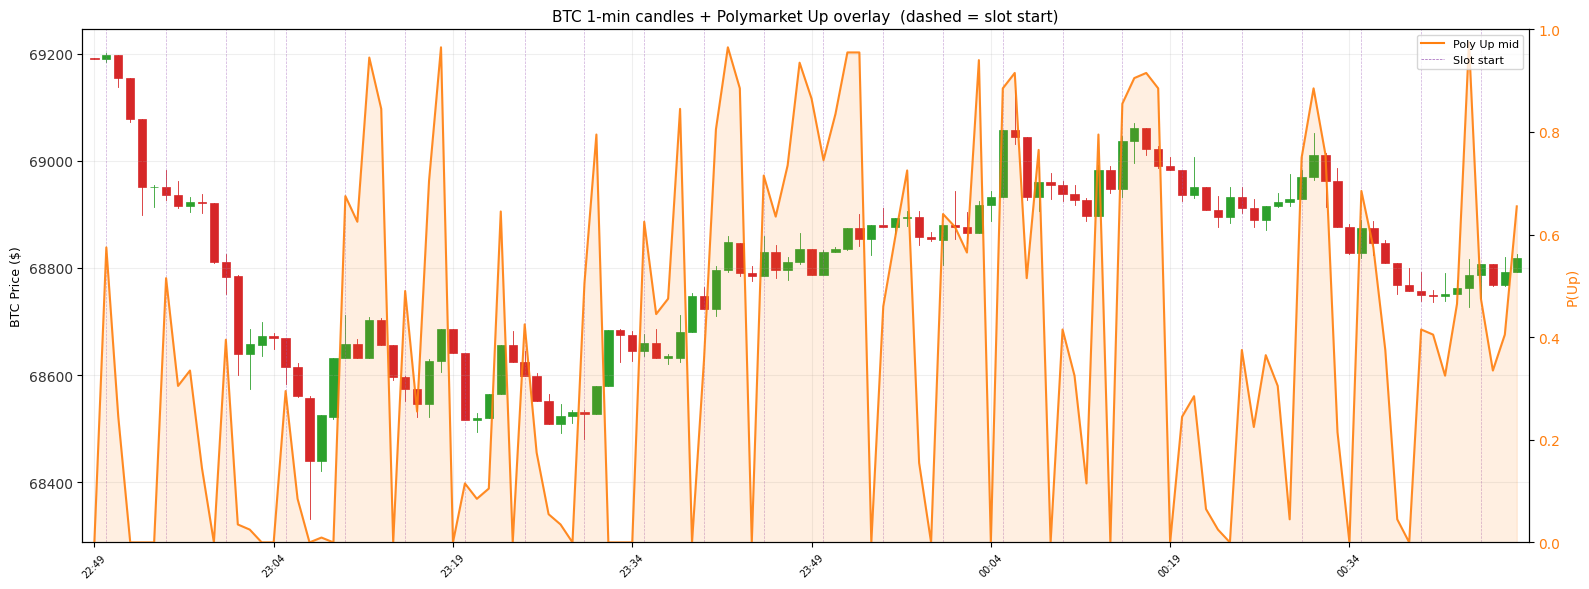

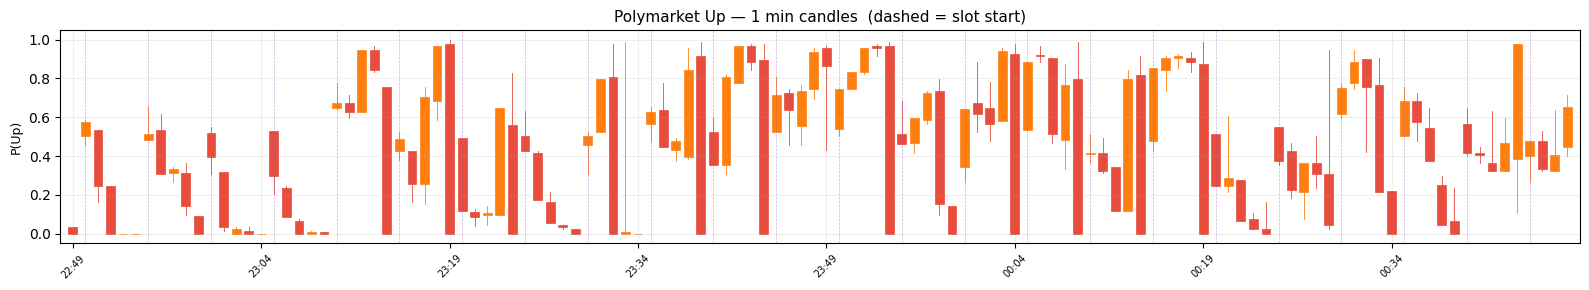

In [114]:
def plot_candles(ax, df, title, ylabel, color_up='#2ca02c', color_dn='#d62728'):
    """Minimal candlestick renderer."""
    x = np.arange(len(df))
    for i, (_, row) in enumerate(df.iterrows()):
        o, h, l, c = row['open'], row['high'], row['low'], row['close']
        color = color_up if c >= o else color_dn
        ax.plot([i, i], [l, h], color=color, lw=0.6)
        body_lo, body_hi = min(o, c), max(o, c)
        body_h = max(body_hi - body_lo, (h - l) * 0.01)
        ax.add_patch(Rectangle((i - 0.35, body_lo), 0.7, body_h,
                               facecolor=color, edgecolor=color, lw=0.5))
    ax.set_xlim(-1, len(df))
    step = max(1, len(df) // 8)
    ticks = list(range(0, len(df), step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(df.index[t].strftime('%H:%M')) for t in ticks],
                       rotation=45, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)

# Compute slot start times for vertical markers
slot_starts = pd.to_datetime(ob_raw['slot_ts'].unique(), unit='s', utc=True)

# Show a ~2h window
n = min(120, len(btc), len(poly))
btc_sl  = btc.iloc[:n]
poly_sl = poly.iloc[:n]

fig, ax1 = plt.subplots(figsize=(16, 6))

# Primary axis: BTC candles
plot_candles(ax1, btc_sl, '', 'BTC Price ($)')
ax1.tick_params(axis='y', labelcolor='#333')

# Secondary axis: Polymarket Up probability line + fill
ax2 = ax1.twinx()
x = np.arange(len(poly_sl))
poly_close = poly_sl['close'].values
ax2.fill_between(x, poly_close, alpha=0.12, color='#ff7f0e')
ax2.plot(x, poly_close, color='#ff7f0e', lw=1.5, alpha=0.9, label='Poly Up mid')
ax2.set_ylabel('P(Up)', fontsize=10, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim(0, 1)

# Slot start markers (vertical dashed lines)
for st in slot_starts:
    if st < btc_sl.index[0] or st > btc_sl.index[-1]:
        continue
    # find the nearest bar index
    idx = btc_sl.index.searchsorted(st)
    if 0 <= idx < n:
        ax1.axvline(idx, color='#9b59b6', lw=0.5, ls='--', alpha=0.5)

# Add a legend entry for slot markers
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='#ff7f0e', lw=1.5, label='Poly Up mid'),
    Line2D([0], [0], color='#9b59b6', lw=0.5, ls='--', label='Slot start'),
]
ax2.legend(handles=handles, loc='upper right', fontsize=8)
ax1.set_title('BTC 1-min candles + Polymarket Up overlay  (dashed = slot start)', fontsize=11)
plt.tight_layout()
plt.show()

# Also show Polymarket candles separately for reference
fig, ax = plt.subplots(figsize=(16, 3))
plot_candles(ax, poly_sl, 'Polymarket Up — 1 min candles', 'P(Up)',
             color_up='#ff7f0e', color_dn='#e74c3c')
for st in slot_starts:
    if st < poly_sl.index[0] or st > poly_sl.index[-1]:
        continue
    idx = poly_sl.index.searchsorted(st)
    if 0 <= idx < n:
        ax.axvline(idx, color='#9b59b6', lw=0.5, ls='--', alpha=0.5)
ax.set_title('Polymarket Up — 1 min candles  (dashed = slot start)', fontsize=11)
plt.tight_layout()
plt.show()


## 3. Compute all candidate indicators on BTC 1-min

We compute 25 indicators from BTC candles (16 standard + 9 TD Sequential),
then measure which one best correlates with Polymarket Up-side price direction.

In [120]:
c = btc['close']
h = btc['high']
l = btc['low']
v = btc['volume'].replace(0, np.nan)

# --- Momentum ---
# RSI(14)
delta = c.diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)
avg_g = gain.ewm(alpha=1/14, adjust=False).mean()
avg_l = loss.ewm(alpha=1/14, adjust=False).mean()
btc['rsi_14'] = 100 - 100 / (1 + avg_g / avg_l.replace(0, np.nan))

# Stochastic %K(14)
lo14 = l.rolling(14).min()
hi14 = h.rolling(14).max()
btc['stoch_k'] = 100 * (c - lo14) / (hi14 - lo14).replace(0, np.nan)

# Williams %R(14)
btc['williams_r'] = -100 * (hi14 - c) / (hi14 - lo14).replace(0, np.nan)

# CCI(20)
tp = (h + l + c) / 3
sma_tp = tp.rolling(20).mean()
mad_tp = tp.rolling(20).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
btc['cci_20'] = (tp - sma_tp) / (0.015 * mad_tp.replace(0, np.nan))

# --- Trend ---
# MACD (12,26,9)
ema12 = c.ewm(span=12).mean()
ema26 = c.ewm(span=26).mean()
btc['macd_line'] = ema12 - ema26
btc['macd_signal'] = btc['macd_line'].ewm(span=9).mean()
btc['macd_hist'] = btc['macd_line'] - btc['macd_signal']

# ADX(14)
plus_dm = h.diff().clip(lower=0)
minus_dm = (-l.diff()).clip(lower=0)
tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
atr14 = tr.ewm(span=14).mean()
plus_di = 100 * plus_dm.ewm(span=14).mean() / atr14.replace(0, np.nan)
minus_di = 100 * minus_dm.ewm(span=14).mean() / atr14.replace(0, np.nan)
dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
btc['adx_14'] = dx.ewm(span=14).mean()
btc['plus_di'] = plus_di
btc['minus_di'] = minus_di

# --- Volatility ---
# Bollinger %B(20,2)
sma20 = c.rolling(20).mean()
std20 = c.rolling(20).std()
btc['boll_pctb'] = (c - (sma20 - 2*std20)) / (4*std20).replace(0, np.nan)

# ATR(14)
btc['atr_14'] = atr14

# --- Volume ---
# OBV (On Balance Volume)
obv_sign = np.sign(delta).fillna(0)
btc['obv'] = (obv_sign * v.fillna(0)).cumsum()

# MFI(14)
mf = tp * v.fillna(0)
pos_mf = (mf * (delta > 0)).rolling(14).sum()
neg_mf = (mf * (delta <= 0)).rolling(14).sum()
btc['mfi_14'] = 100 - 100 / (1 + pos_mf / neg_mf.replace(0, np.nan))

# VWAP deviation
cum_pv = (tp * v.fillna(0)).cumsum()
cum_v  = v.fillna(0).cumsum()
vwap = cum_pv / cum_v.replace(0, np.nan)
btc['vwap_dev'] = (c - vwap) / vwap.replace(0, np.nan)

# --- Returns ---
btc['ret_1m'] = c.pct_change()
btc['ret_5m'] = c.pct_change(5)

# --- TD Sequential (using repo's indicator) ---
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from indicators.base import IndicatorConfig
from indicators.td_sequential import TDSequentialIndicator

_tds = TDSequentialIndicator(IndicatorConfig("TDSeq", {}))
td_vals = _tds.compute(btc).values

btc['td_bull_setup'] = td_vals['bullish_setup_count']   # 0–9: consecutive close < close[4]
btc['td_bear_setup'] = td_vals['bearish_setup_count']   # 0–9: consecutive close > close[4]
btc['td_net_setup']  = td_vals['bearish_setup_count'] - td_vals['bullish_setup_count']  # +ve = bearish
btc['td_buy_9']      = td_vals['bullish_setup_complete'].astype(float)   # 1 when buy setup hits 9
btc['td_sell_9']     = td_vals['bearish_setup_complete'].astype(float)   # 1 when sell setup hits 9
btc['td_buy_cd']     = td_vals['buy_cd_count']           # buy countdown progress (0–13)
btc['td_sell_cd']    = td_vals['sell_cd_count']           # sell countdown progress (0–13)

# TDST support/resistance distance from current price
tdst = TDSequentialIndicator._compute_tdst_levels(
    btc, td_vals['bullish_setup_complete'], td_vals['bearish_setup_complete']
)
btc['td_support_dist']    = (c - pd.Series(tdst['tdst_support'], index=btc.index)) / c
btc['td_resistance_dist'] = (pd.Series(tdst['tdst_resistance'], index=btc.index) - c) / c

print(f'TD Sequential: buy_9 fired {int(btc.td_buy_9.sum())}x, '
      f'sell_9 fired {int(btc.td_sell_9.sum())}x over {len(btc)} bars')

INDICATORS = [
    # standard
    'rsi_14', 'stoch_k', 'williams_r', 'cci_20',
    'macd_line', 'macd_hist',
    'adx_14', 'plus_di', 'minus_di',
    'boll_pctb', 'atr_14',
    'obv', 'mfi_14', 'vwap_dev',
    'ret_1m', 'ret_5m',
    # TD Sequential
    'td_bull_setup', 'td_bear_setup', 'td_net_setup',
    'td_buy_9', 'td_sell_9',
    'td_buy_cd', 'td_sell_cd',
    'td_support_dist', 'td_resistance_dist',
]
print(f'{len(INDICATORS)} indicators computed on {len(btc)} bars')

TD Sequential: buy_9 fired 22x, sell_9 fired 17x over 1781 bars
25 indicators computed on 1781 bars


## 4. Polymarket target variable

We define two targets:
- `poly_ret`: 1-min return of Polymarket Up mid (continuous)
- `poly_dir`: +1 if Up mid rose, -1 if it fell (binary direction)

In [122]:
# Align BTC indicators with Polymarket returns
merged = btc[INDICATORS].copy()
merged['poly_close'] = poly['close'].reindex(merged.index)
merged = merged.dropna(subset=['poly_close'])

# Polymarket 1-bar-ahead return (what we want to predict)
merged['poly_ret'] = merged['poly_close'].pct_change().shift(-1)
merged['poly_dir'] = np.sign(merged['poly_close'].diff().shift(-1))
# merged = merged.dropna()
print(f'{len(merged)} aligned rows')
print(f'Poly direction balance: Up={int((merged.poly_dir>0).sum())}  '
      f'Down={int((merged.poly_dir<0).sum())}  Flat={int((merged.poly_dir==0).sum())}')

1781 aligned rows
Poly direction balance: Up=844  Down=846  Flat=90


## 5. Correlation ranking — which indicator predicts Polymarket best?

Three measures for each indicator:
- **Pearson r** with poly_ret (linear relationship with magnitude)
- **Spearman rho** with poly_ret (monotonic, robust to outliers)
- **Point-biserial r** with poly_dir (does the indicator level predict direction?)

In [123]:
results = []
for ind in INDICATORS:
    x = merged[ind].values
    y_ret = merged['poly_ret'].values
    y_dir = merged['poly_dir'].values

    mask = np.isfinite(x) & np.isfinite(y_ret)
    if mask.sum() < 30:
        continue

    pr, pp = stats.pearsonr(x[mask], y_ret[mask])
    sr, sp = stats.spearmanr(x[mask], y_ret[mask])

    # Point-biserial: indicator level → direction (exclude flat)
    dir_mask = mask & (y_dir != 0)
    if dir_mask.sum() > 30:
        pb, pbp = stats.pointbiserialr((y_dir[dir_mask] > 0).astype(int), x[dir_mask])
    else:
        pb, pbp = np.nan, np.nan

    results.append({
        'indicator': ind,
        'pearson_r': pr, 'pearson_p': pp,
        'spearman_rho': sr, 'spearman_p': sp,
        'ptbiserial_r': pb, 'ptbiserial_p': pbp,
    })

corr = pd.DataFrame(results)
corr['abs_pearson'] = corr['pearson_r'].abs()
corr['abs_spearman'] = corr['spearman_rho'].abs()
corr['abs_ptbiserial'] = corr['ptbiserial_r'].abs()
corr = corr.sort_values('abs_spearman', ascending=False)

print('Ranked by |Spearman rho| with 1-bar-ahead Polymarket return:\n')
display_cols = ['indicator', 'pearson_r', 'spearman_rho', 'ptbiserial_r',
                'spearman_p']
corr[display_cols].round(4)

Ranked by |Spearman rho| with 1-bar-ahead Polymarket return:



,indicator,pearson_r,spearman_rho,ptbiserial_r,spearman_p
14,ret_1m,0.0105,0.0604,0.1162,0.0251
20,td_sell_9,-0.0190,-0.0456,-0.0315,0.0908
5,macd_hist,-0.0227,-0.0382,-0.0142,0.1570
16,td_bull_setup,-0.0259,-0.0358,-0.0397,0.1840
6,adx_14,-0.0456,-0.0349,-0.0280,0.1960
10,atr_14,-0.0460,-0.0298,0.0016,0.2688
22,td_sell_cd,-0.0228,-0.0285,-0.0341,0.2905
2,williams_r,-0.0173,-0.0245,0.0313,0.3651
1,stoch_k,-0.0173,-0.0245,0.0313,0.3651
18,td_net_setup,-0.0079,0.0189,0.0372,0.4846


## 6. Visual: top 4 indicators vs Polymarket

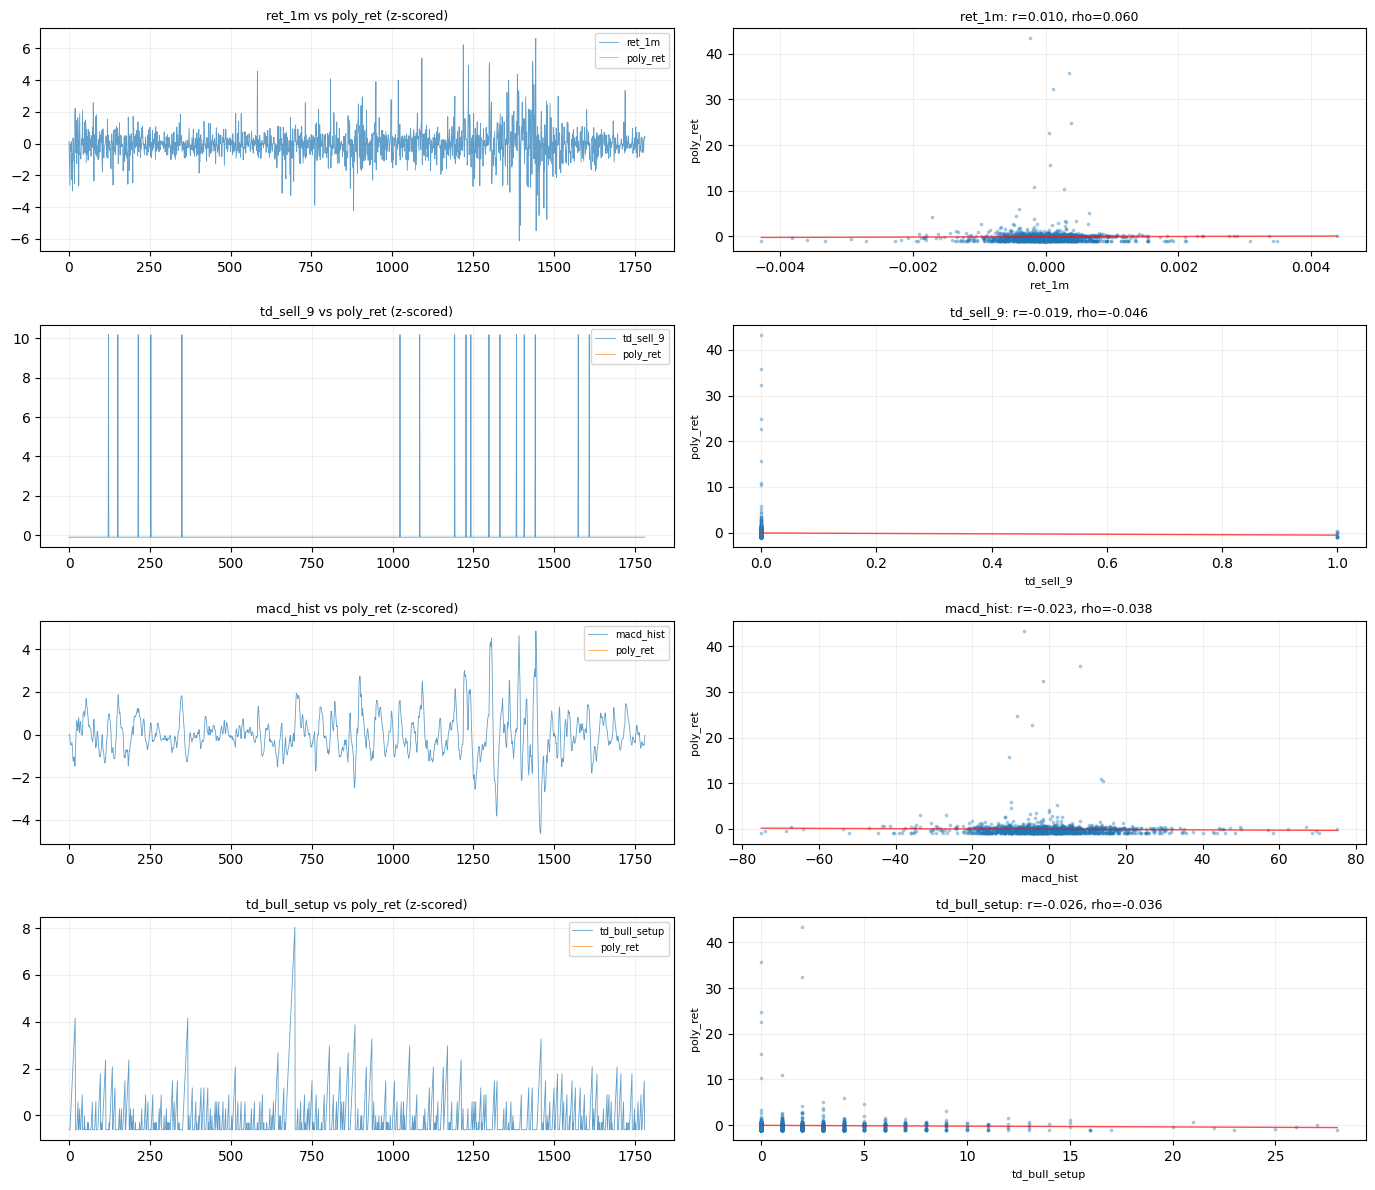

In [124]:
top4 = corr.head(4)['indicator'].tolist()

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for i, ind in enumerate(top4):
    ax_ts = axes[i, 0]
    ax_sc = axes[i, 1]

    x = merged[ind]
    y = merged['poly_ret']

    # Time series overlay (normalized)
    x_norm = (x - x.mean()) / x.std()
    y_norm = (y - y.mean()) / y.std()
    ax_ts.plot(np.arange(len(x_norm)), x_norm.values, lw=0.6, alpha=0.7, label=ind)
    ax_ts.plot(np.arange(len(y_norm)), y_norm.values, lw=0.6, alpha=0.7, label='poly_ret')
    ax_ts.set_title(f'{ind} vs poly_ret (z-scored)', fontsize=9)
    ax_ts.legend(fontsize=7, loc='upper right')
    ax_ts.grid(True, alpha=0.2)

    # Scatter
    ax_sc.scatter(x.values, y.values, s=3, alpha=0.3, c='#1f77b4')
    r = corr[corr.indicator == ind].iloc[0]
    ax_sc.set_title(f'{ind}: r={r.pearson_r:.3f}, rho={r.spearman_rho:.3f}', fontsize=9)
    ax_sc.set_xlabel(ind, fontsize=8)
    ax_sc.set_ylabel('poly_ret', fontsize=8)
    # Trend line
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() > 10:
        z = np.polyfit(x[mask], y[mask], 1)
        ax_sc.plot(sorted(x[mask]), np.polyval(z, sorted(x[mask])),
                   'r-', lw=1, alpha=0.7)
    ax_sc.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Lead-lag analysis — does the indicator LEAD Polymarket?

A useful indicator must **lead** Polymarket, not just correlate contemporaneously.
Cross-correlate top indicators at lags -5..+5 minutes.

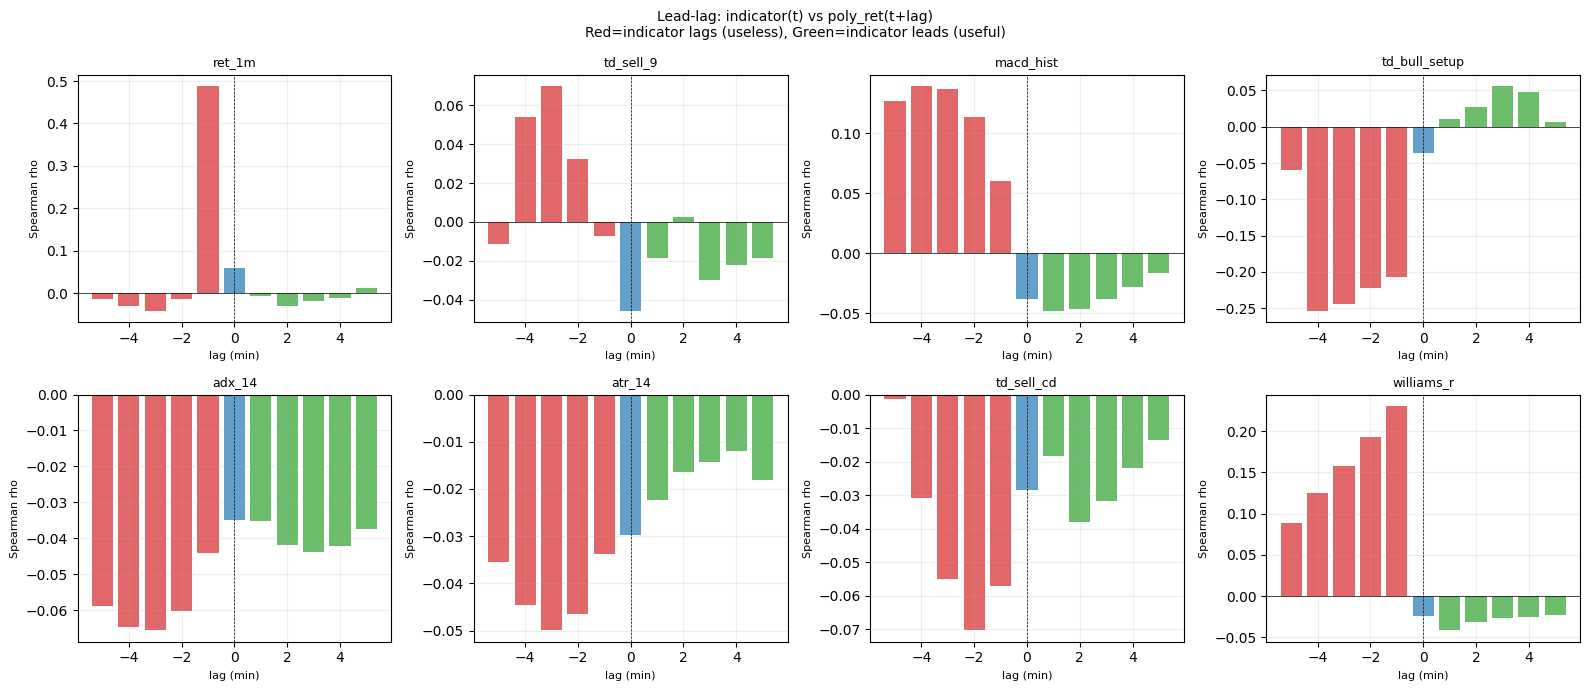

In [125]:
top8 = corr.head(8)['indicator'].tolist()
lags = range(-5, 6)

nrows = (len(top8) + 3) // 4
fig, axes = plt.subplots(nrows, 4, figsize=(16, 3.5 * nrows))
for idx, ind in enumerate(top8):
    ax = axes.flat[idx]
    x = merged[ind].values
    y = merged['poly_ret'].values
    cors = []
    for lag in lags:
        if lag >= 0:
            xi, yi = x[:len(x)-lag], y[lag:]
        else:
            xi, yi = x[-lag:], y[:len(y)+lag]
        mask = np.isfinite(xi) & np.isfinite(yi)
        if mask.sum() < 30:
            cors.append(0)
        else:
            cors.append(stats.spearmanr(xi[mask], yi[mask])[0])

    colors = ['#d62728' if l < 0 else '#2ca02c' if l > 0 else '#1f77b4'
              for l in lags]
    ax.bar(list(lags), cors, color=colors, alpha=0.7)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'{ind}', fontsize=9)
    ax.set_xlabel('lag (min)', fontsize=8)
    ax.set_ylabel('Spearman rho', fontsize=8)
    ax.grid(True, alpha=0.2)

for idx in range(len(top8), len(axes.flat)):
    axes.flat[idx].set_visible(False)

fig.suptitle('Lead-lag: indicator(t) vs poly_ret(t+lag)\n'
             'Red=indicator lags (useless), Green=indicator leads (useful)',
             fontsize=10)
plt.tight_layout()
plt.show()

## 8. Directional accuracy — if indicator says Up, does Poly go Up?

For each indicator, split into quintiles and measure the win rate
(% of times Polymarket moved in the predicted direction) per quintile.

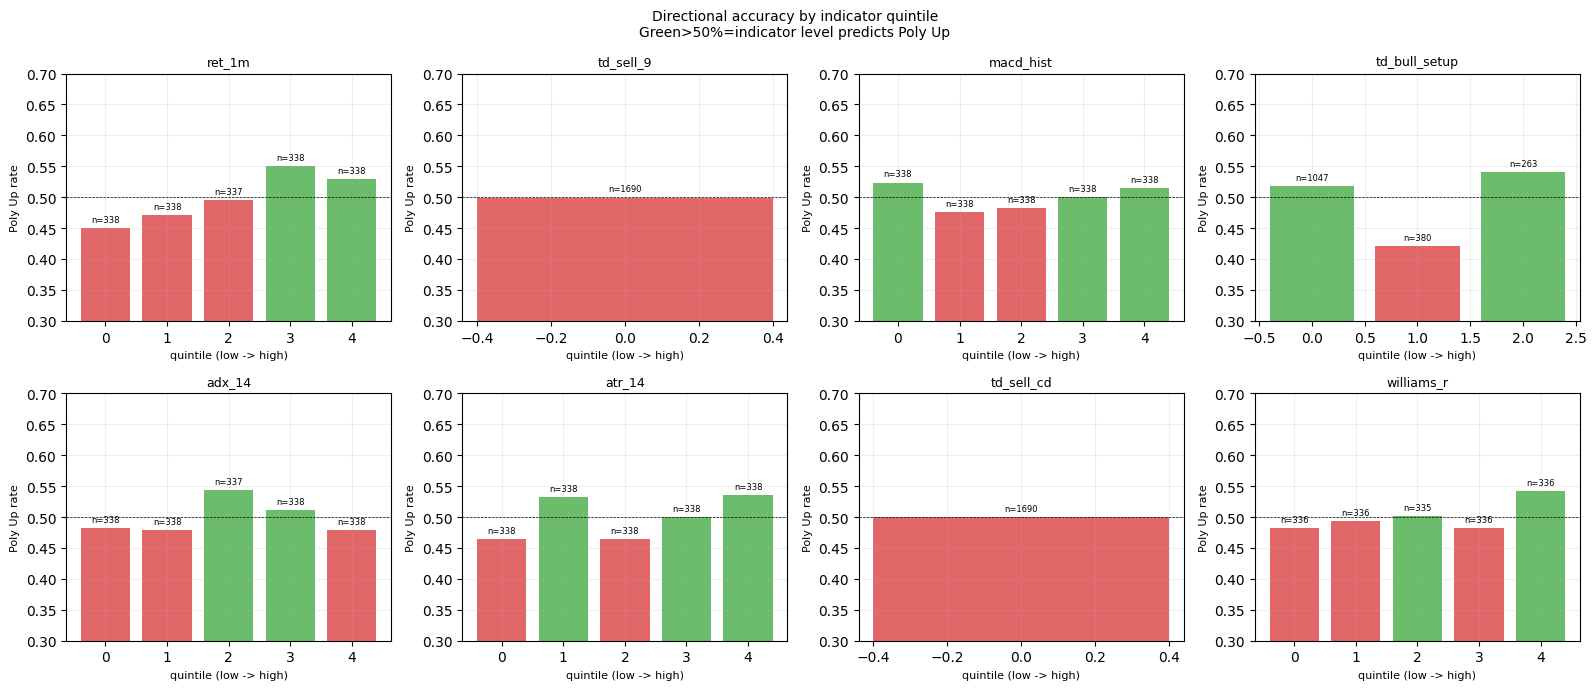

In [126]:
nrows = (len(top8) + 3) // 4
fig, axes = plt.subplots(nrows, 4, figsize=(16, 3.5 * nrows))
for idx, ind in enumerate(top8):
    ax = axes.flat[idx]
    tmp = merged[[ind, 'poly_dir']].dropna()
    tmp = tmp[tmp['poly_dir'] != 0]  # drop flat
    try:
        tmp['q'] = pd.qcut(tmp[ind], 5, labels=False, duplicates='drop')
    except ValueError:
        tmp['q'] = pd.cut(tmp[ind], 5, labels=False)
    grp = tmp.groupby('q').agg(
        n=('poly_dir', 'size'),
        up_rate=('poly_dir', lambda s: (s > 0).mean()),
        mean_ind=(ind, 'mean'),
    )
    colors = ['#d62728' if r < 0.5 else '#2ca02c' for r in grp['up_rate']]
    ax.bar(grp.index, grp['up_rate'], color=colors, alpha=0.7)
    ax.axhline(0.5, color='k', lw=0.5, ls='--')
    ax.set_title(f'{ind}', fontsize=9)
    ax.set_xlabel('quintile (low -> high)', fontsize=8)
    ax.set_ylabel('Poly Up rate', fontsize=8)
    ax.set_ylim(0.3, 0.7)
    for j, row in grp.iterrows():
        ax.text(j, row['up_rate'] + 0.01, f'n={int(row.n)}', ha='center', fontsize=6)
    ax.grid(True, alpha=0.2)

for idx in range(len(top8), len(axes.flat)):
    axes.flat[idx].set_visible(False)

fig.suptitle('Directional accuracy by indicator quintile\n'
             'Green>50%=indicator level predicts Poly Up', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Summary table

In [127]:
# Compute directional accuracy for each indicator
for i, row in corr.iterrows():
    ind = row['indicator']
    tmp = merged[[ind, 'poly_dir']].dropna()
    tmp = tmp[tmp['poly_dir'] != 0]
    if len(tmp) < 30:
        corr.loc[i, 'dir_acc_top_q'] = np.nan
        continue
    try:
        q = pd.qcut(tmp[ind], 5, labels=False, duplicates='drop')
    except ValueError:
        q = pd.cut(tmp[ind], 5, labels=False)
    top_q = tmp[q == q.max()]
    corr.loc[i, 'dir_acc_top_q'] = float((top_q['poly_dir'] > 0).mean())

summary = corr[['indicator', 'spearman_rho', 'spearman_p',
                'ptbiserial_r', 'dir_acc_top_q']].copy()
summary.columns = ['indicator', 'spearman', 'p_value', 'direction_r', 'top_quintile_up%']
summary = summary.sort_values('spearman', key=abs, ascending=False)
print('Final ranking — |Spearman| with 1-bar-ahead Polymarket return:\n')
summary.round(4)

Final ranking — |Spearman| with 1-bar-ahead Polymarket return:



,indicator,spearman,p_value,direction_r,top_quintile_up%
14,ret_1m,0.0604,0.0251,0.1162,0.5296
20,td_sell_9,-0.0456,0.0908,-0.0315,0.4994
5,macd_hist,-0.0382,0.1570,-0.0142,0.5148
16,td_bull_setup,-0.0358,0.1840,-0.0397,0.5399
6,adx_14,-0.0349,0.1960,-0.0280,0.4793
10,atr_14,-0.0298,0.2688,0.0016,0.5355
22,td_sell_cd,-0.0285,0.2905,-0.0341,0.4994
2,williams_r,-0.0245,0.3651,0.0313,0.5417
1,stoch_k,-0.0245,0.3651,0.0313,0.5417
18,td_net_setup,0.0189,0.4846,0.0372,0.5556


## Interpretation guide

| What to look for | Why it matters |
|---|---|
| **High \|Spearman\|** | Monotonic relationship — indicator level predicts return magnitude |
| **p < 0.05** | Statistically significant, not noise |
| **Lead-lag peaks at lag > 0** | Indicator *leads* Polymarket (predictive, not just correlated) |
| **Monotone quintile bars** | Higher indicator → higher Poly Up rate (or inverse). Monotonicity = usable signal |
| **Top quintile up% far from 50%** | The extreme indicator readings carry directional edge |

An ideal indicator would show: high Spearman, significant p-value, peak correlation at lag +1 or +2 (leads), and a clean monotonic quintile staircase from low to high Up rate.

---

## 10. Multi-timeframe indicator charts (1m / 3m / 5m)

Each indicator shown on actual BTC candlestick charts — top panel is price candles,
bottom panel is the indicator value. Three columns: 1-min, 3-min, 5-min.

Polymarket Up probability candles are shown alongside for visual comparison.

In [128]:
# Build 3m and 5m OHLC + indicators for BTC and Polymarket
def build_tf(btc_1s_df, poly_up_df, freq):
    """Resample 1s BTC → freq OHLC, recompute all indicators."""
    b = btc_1s_df.resample(freq).agg({
        'open': 'first', 'high': 'max', 'low': 'min',
        'close': 'last', 'volume': 'sum',
    }).dropna()
    p = poly_up_df.resample(freq).agg({
        'mid': ['first', 'max', 'min', 'last'],
    }).dropna()
    p.columns = ['open', 'high', 'low', 'close']
    # align
    s, e = max(b.index.min(), p.index.min()), min(b.index.max(), p.index.max())
    b, p = b.loc[s:e].copy(), p.loc[s:e].copy()
    # indicators
    c, hi, lo = b['close'], b['high'], b['low']
    vol = b['volume'].replace(0, np.nan)
    d = c.diff()
    # RSI
    g = d.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    ls_ = (-d).clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    b['rsi_14'] = 100 - 100 / (1 + g / ls_.replace(0, np.nan))
    # Stoch %K
    lo14, hi14 = lo.rolling(14).min(), hi.rolling(14).max()
    b['stoch_k'] = 100 * (c - lo14) / (hi14 - lo14).replace(0, np.nan)
    # Williams %R
    b['williams_r'] = -100 * (hi14 - c) / (hi14 - lo14).replace(0, np.nan)
    # CCI
    tp = (hi + lo + c) / 3
    sma_tp = tp.rolling(20).mean()
    mad_tp = tp.rolling(20).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    b['cci_20'] = (tp - sma_tp) / (0.015 * mad_tp.replace(0, np.nan))
    # MACD
    e12, e26 = c.ewm(span=12).mean(), c.ewm(span=26).mean()
    b['macd_line'] = e12 - e26
    b['macd_signal'] = b['macd_line'].ewm(span=9).mean()
    b['macd_hist'] = b['macd_line'] - b['macd_signal']
    # ADX
    pdm = hi.diff().clip(lower=0)
    mdm = (-lo.diff()).clip(lower=0)
    tr = pd.concat([hi-lo, (hi-c.shift()).abs(), (lo-c.shift()).abs()], axis=1).max(axis=1)
    atr = tr.ewm(span=14).mean()
    pdi = 100 * pdm.ewm(span=14).mean() / atr.replace(0, np.nan)
    mdi = 100 * mdm.ewm(span=14).mean() / atr.replace(0, np.nan)
    dx = 100 * (pdi - mdi).abs() / (pdi + mdi).replace(0, np.nan)
    b['adx_14'] = dx.ewm(span=14).mean()
    b['plus_di'], b['minus_di'] = pdi, mdi
    # Boll %B
    sma20 = c.rolling(20).mean(); std20 = c.rolling(20).std()
    b['boll_pctb'] = (c - (sma20 - 2*std20)) / (4*std20).replace(0, np.nan)
    b['atr_14'] = atr
    # OBV
    b['obv'] = (np.sign(d).fillna(0) * vol.fillna(0)).cumsum()
    # MFI
    mf = tp * vol.fillna(0)
    pos_mf = (mf * (d > 0)).rolling(14).sum()
    neg_mf = (mf * (d <= 0)).rolling(14).sum()
    b['mfi_14'] = 100 - 100 / (1 + pos_mf / neg_mf.replace(0, np.nan))
    # VWAP dev
    cum_pv = (tp * vol.fillna(0)).cumsum()
    cum_v = vol.fillna(0).cumsum()
    vwap = cum_pv / cum_v.replace(0, np.nan)
    b['vwap_dev'] = (c - vwap) / vwap.replace(0, np.nan)
    # Returns
    b['ret_1m'] = c.pct_change()
    b['ret_5m'] = c.pct_change(5)
    # TD Sequential
    td = _tds.compute(b).values
    b['td_bull_setup'] = td['bullish_setup_count']
    b['td_bear_setup'] = td['bearish_setup_count']
    b['td_net_setup'] = td['bearish_setup_count'] - td['bullish_setup_count']
    b['td_buy_9'] = td['bullish_setup_complete'].astype(float)
    b['td_sell_9'] = td['bearish_setup_complete'].astype(float)
    b['td_buy_cd'] = td['buy_cd_count']
    b['td_sell_cd'] = td['sell_cd_count']
    tdst_ = TDSequentialIndicator._compute_tdst_levels(
        b, td['bullish_setup_complete'], td['bearish_setup_complete'])
    b['td_support_dist'] = (c - pd.Series(tdst_['tdst_support'], index=b.index)) / c
    b['td_resistance_dist'] = (pd.Series(tdst_['tdst_resistance'], index=b.index) - c) / c
    return b, p

# Prepare 1s indexed sources for resampling
btc_1s = btc_raw.set_index('dt')
poly_1s = up.set_index('dt')

tf_data = {}
for freq, label in [('1min', '1m'), ('3min', '3m'), ('5min', '5m')]:
    b, p = build_tf(btc_1s, poly_1s, freq)
    tf_data[label] = {'btc': b, 'poly': p}
    print(f'{label}: {len(b)} BTC bars, {len(p)} Poly bars')

# Show window: ~90 bars of each TF (so 1m=1.5h, 3m=4.5h, 5m=7.5h)
WIN = 90

1m: 1781 BTC bars, 1781 Poly bars
3m: 596 BTC bars, 596 Poly bars
5m: 359 BTC bars, 359 Poly bars


In [129]:
def draw_candles(ax, df, n, color_up='#2ca02c', color_dn='#d62728'):
    """Draw n candles on ax."""
    sl = df.iloc[:n]
    for i, (_, r) in enumerate(sl.iterrows()):
        o, h_, l_, c_ = r['open'], r['high'], r['low'], r['close']
        col = color_up if c_ >= o else color_dn
        ax.plot([i, i], [l_, h_], color=col, lw=0.5)
        blo, bhi = min(o, c_), max(o, c_)
        bh = max(bhi - blo, (h_ - l_) * 0.008)
        ax.add_patch(Rectangle((i-0.35, blo), 0.7, bh, fc=col, ec=col, lw=0.4))
    ax.set_xlim(-1, n)
    step = max(1, n // 6)
    ticks = list(range(0, n, step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([sl.index[t].strftime('%H:%M') for t in ticks],
                       rotation=45, fontsize=6)

def add_slot_markers(ax, df, n):
    """Add vertical dashed lines at Polymarket slot starts."""
    sl = df.iloc[:n]
    for st in slot_starts:
        if st < sl.index[0] or st > sl.index[-1]:
            continue
        idx = sl.index.searchsorted(st)
        if 0 <= idx < n:
            ax.axvline(idx, color='#9b59b6', lw=0.3, ls='--', alpha=0.35)

def chart_indicator_group(title, indicators_spec, tf_labels=('1m','3m','5m')):
    ncols = len(tf_labels)
    nrows = 1 + len(indicators_spec)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 2.2*nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]
    if ncols == 1:
        axes = axes[:, np.newaxis]

    for ci, tf in enumerate(tf_labels):
        b = tf_data[tf]['btc']
        p = tf_data[tf]['poly']
        n = min(WIN, len(b))
        sl = b.iloc[:n]

        # Row 0: BTC candles + Poly overlay + slot markers
        ax = axes[0, ci]
        draw_candles(ax, b, n)
        add_slot_markers(ax, b, n)
        ax2 = ax.twinx()
        poly_sl = p.iloc[:n]
        ax2.fill_between(np.arange(len(poly_sl)), poly_sl['close'].values,
                         alpha=0.1, color='#ff7f0e')
        ax2.plot(np.arange(len(poly_sl)), poly_sl['close'].values,
                 color='#ff7f0e', lw=0.8, alpha=0.7)
        ax2.set_ylabel('P(Up)', fontsize=7, color='#ff7f0e')
        ax2.tick_params(axis='y', labelsize=6, colors='#ff7f0e')
        ax2.set_ylim(0, 1)
        ax.set_ylabel('BTC', fontsize=7)
        ax.tick_params(axis='y', labelsize=6)
        ax.set_title(f'{tf} — {title}', fontsize=9, fontweight='bold')

        # Indicator rows
        for ri, spec in enumerate(indicators_spec):
            ax = axes[ri + 1, ci]
            x = np.arange(n)
            style = spec.get('style', 'line')
            cols = spec['cols']
            colors = spec.get('colors', ['#1f77b4', '#d62728', '#2ca02c', '#9467bd'])

            for j, col in enumerate(cols):
                vals = sl[col].values if col in sl else np.zeros(n)
                clr = colors[j % len(colors)]
                if style in ('line', 'oscillator'):
                    ax.plot(x, vals, lw=0.8, color=clr, label=col, alpha=0.85)
                elif style == 'histogram':
                    pos = np.where(vals >= 0, vals, 0)
                    neg = np.where(vals < 0, vals, 0)
                    ax.bar(x, pos, width=0.7, color='#2ca02c', alpha=0.6)
                    ax.bar(x, neg, width=0.7, color='#d62728', alpha=0.6)
                    if len(cols) > 1 and j > 0:
                        ax.plot(x, vals, lw=0.7, color=clr, alpha=0.8)
                elif style == 'bar':
                    cmap = ['#2ca02c' if v > 0 else '#d62728' if v < 0 else '#888'
                            for v in vals]
                    ax.bar(x, vals, width=0.7, color=cmap, alpha=0.6)
                elif style == 'markers':
                    mask = vals > 0
                    price = sl['close'].values
                    ax.plot(x, price, lw=0.4, color='#888', alpha=0.5)
                    ax.scatter(x[mask], price[mask], s=18, color=clr,
                               zorder=3, label=col, marker='^' if 'buy' in col else 'v')

            for lev in spec.get('levels', []):
                ax.axhline(lev, color='#888', lw=0.4, ls='--')

            if spec.get('ylim'):
                ax.set_ylim(spec['ylim'])
            ax.set_xlim(-1, n)
            ax.set_ylabel(spec.get('label', ''), fontsize=7)
            ax.tick_params(axis='y', labelsize=6)
            ax.tick_params(axis='x', labelsize=6)
            ax.legend(fontsize=5, loc='upper left', ncol=len(cols))
            ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()


### 10a. Momentum oscillators — RSI, Stochastic %K, Williams %R, CCI

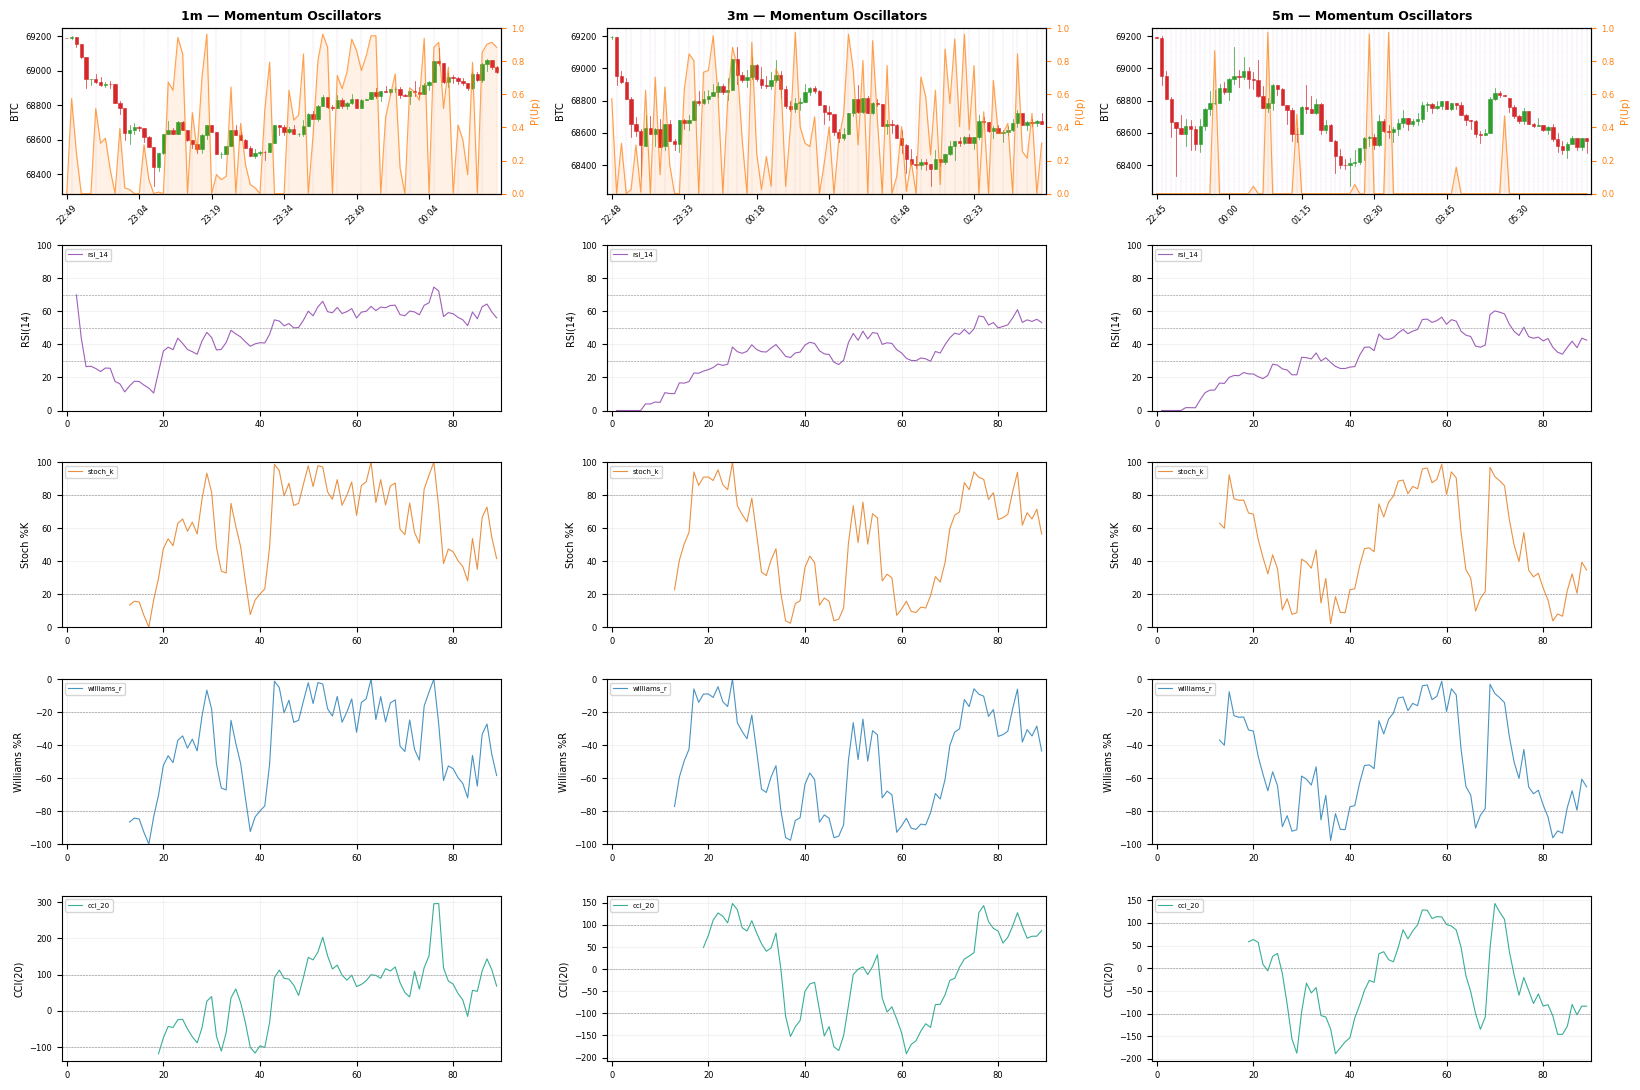

In [130]:
chart_indicator_group('Momentum Oscillators', [
    {'cols': ['rsi_14'], 'style': 'oscillator', 'levels': [30, 50, 70],
     'ylim': (0, 100), 'label': 'RSI(14)', 'colors': ['#8e44ad']},
    {'cols': ['stoch_k'], 'style': 'oscillator', 'levels': [20, 80],
     'ylim': (0, 100), 'label': 'Stoch %K', 'colors': ['#e67e22']},
    {'cols': ['williams_r'], 'style': 'oscillator', 'levels': [-80, -20],
     'ylim': (-100, 0), 'label': 'Williams %R', 'colors': ['#2980b9']},
    {'cols': ['cci_20'], 'style': 'line', 'levels': [-100, 0, 100],
     'label': 'CCI(20)', 'colors': ['#16a085']},
])

### 10b. Trend — MACD, ADX / DI

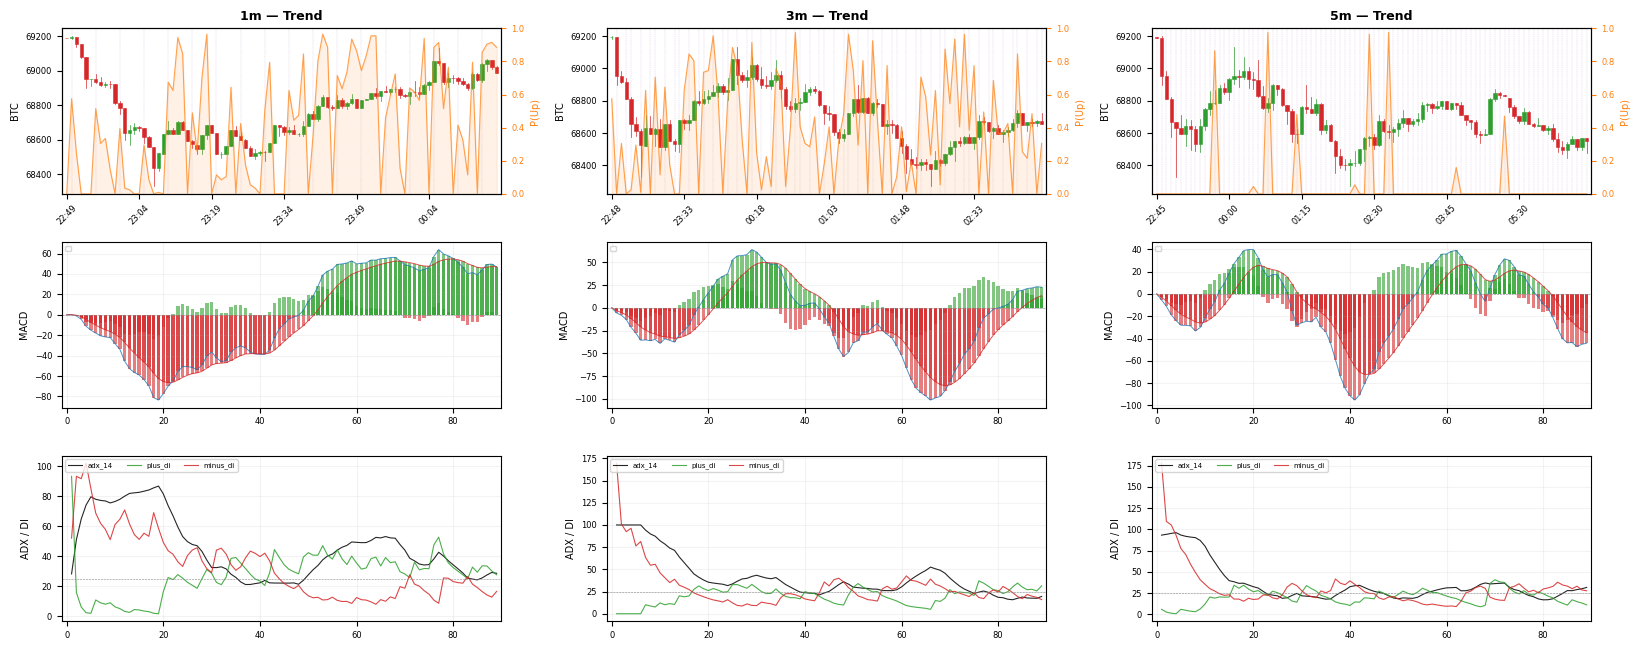

In [131]:
chart_indicator_group('Trend', [
    {'cols': ['macd_hist', 'macd_line', 'macd_signal'], 'style': 'histogram',
     'levels': [0], 'label': 'MACD', 'colors': ['#2ca02c', '#1f77b4', '#d62728']},
    {'cols': ['adx_14', 'plus_di', 'minus_di'], 'style': 'line',
     'levels': [25], 'label': 'ADX / DI',
     'colors': ['#000000', '#2ca02c', '#d62728']},
])

### 10c. Volatility & Volume — Bollinger %B, ATR, MFI, VWAP deviation

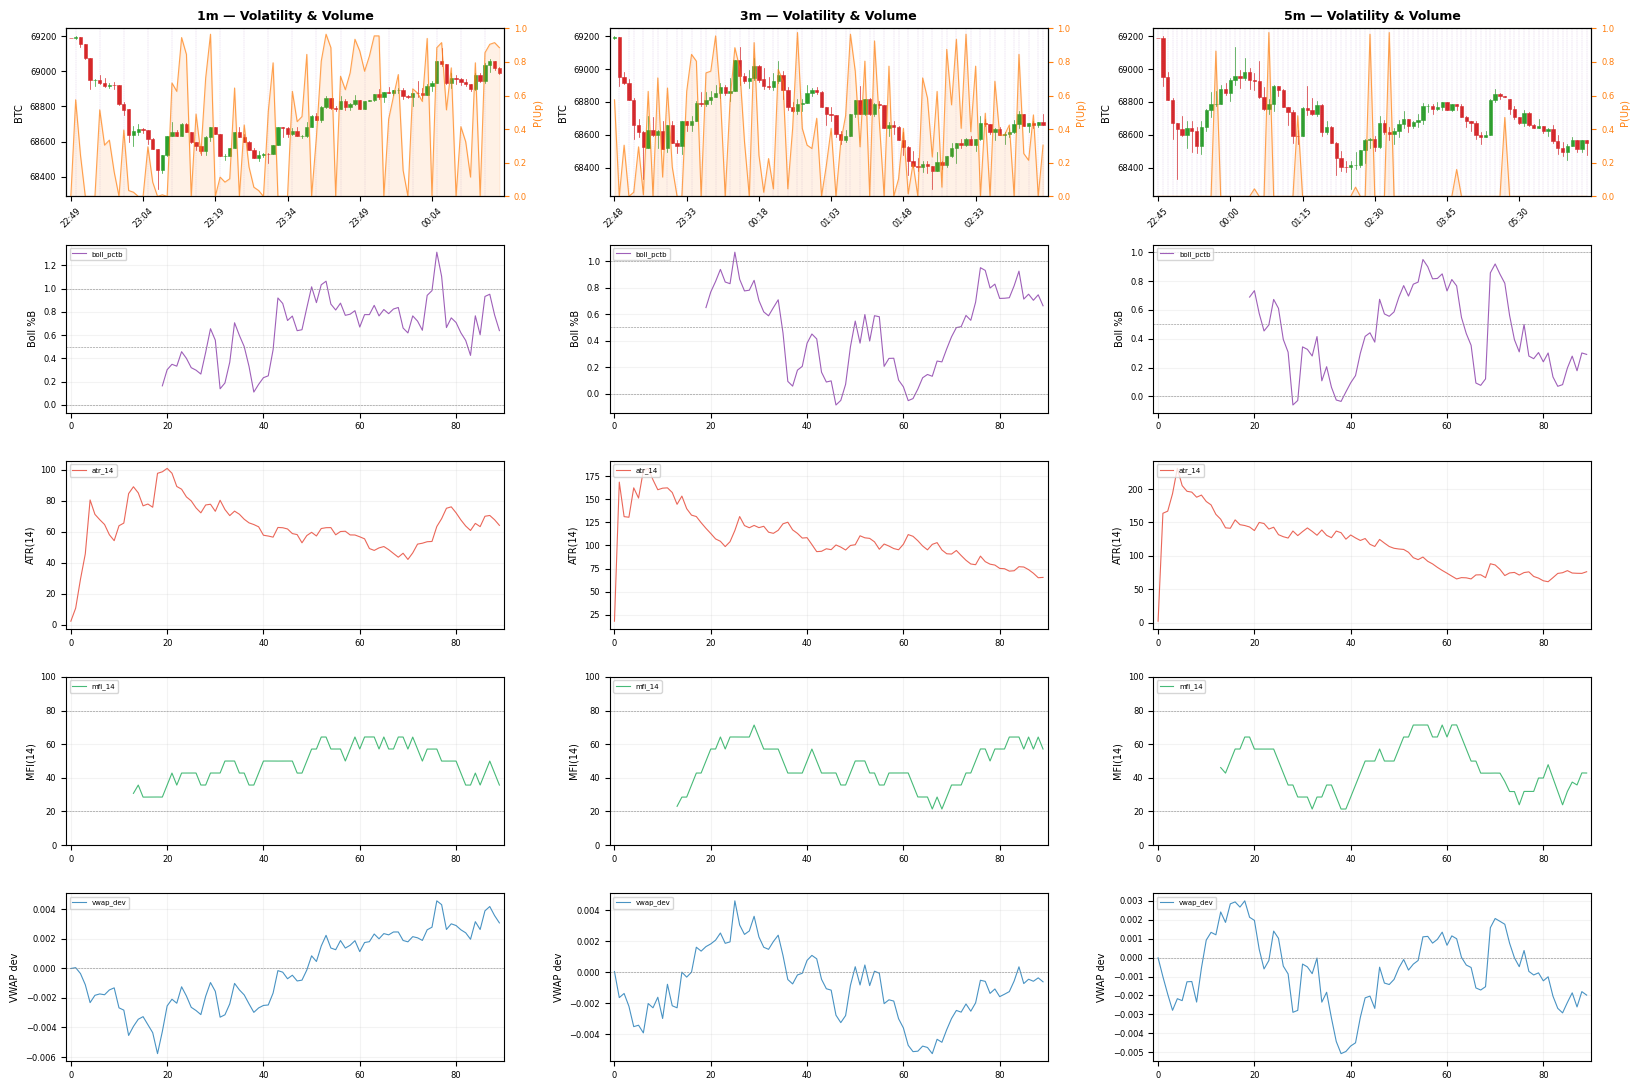

In [132]:
chart_indicator_group('Volatility & Volume', [
    {'cols': ['boll_pctb'], 'style': 'oscillator', 'levels': [0, 0.5, 1.0],
     'label': 'Boll %B', 'colors': ['#8e44ad']},
    {'cols': ['atr_14'], 'style': 'line', 'levels': [],
     'label': 'ATR(14)', 'colors': ['#e74c3c']},
    {'cols': ['mfi_14'], 'style': 'oscillator', 'levels': [20, 80],
     'ylim': (0, 100), 'label': 'MFI(14)', 'colors': ['#27ae60']},
    {'cols': ['vwap_dev'], 'style': 'line', 'levels': [0],
     'label': 'VWAP dev', 'colors': ['#2980b9']},
])

### 10d. TD Sequential — setup counts, buy 9 / sell 9 signals, countdown, TDST distance

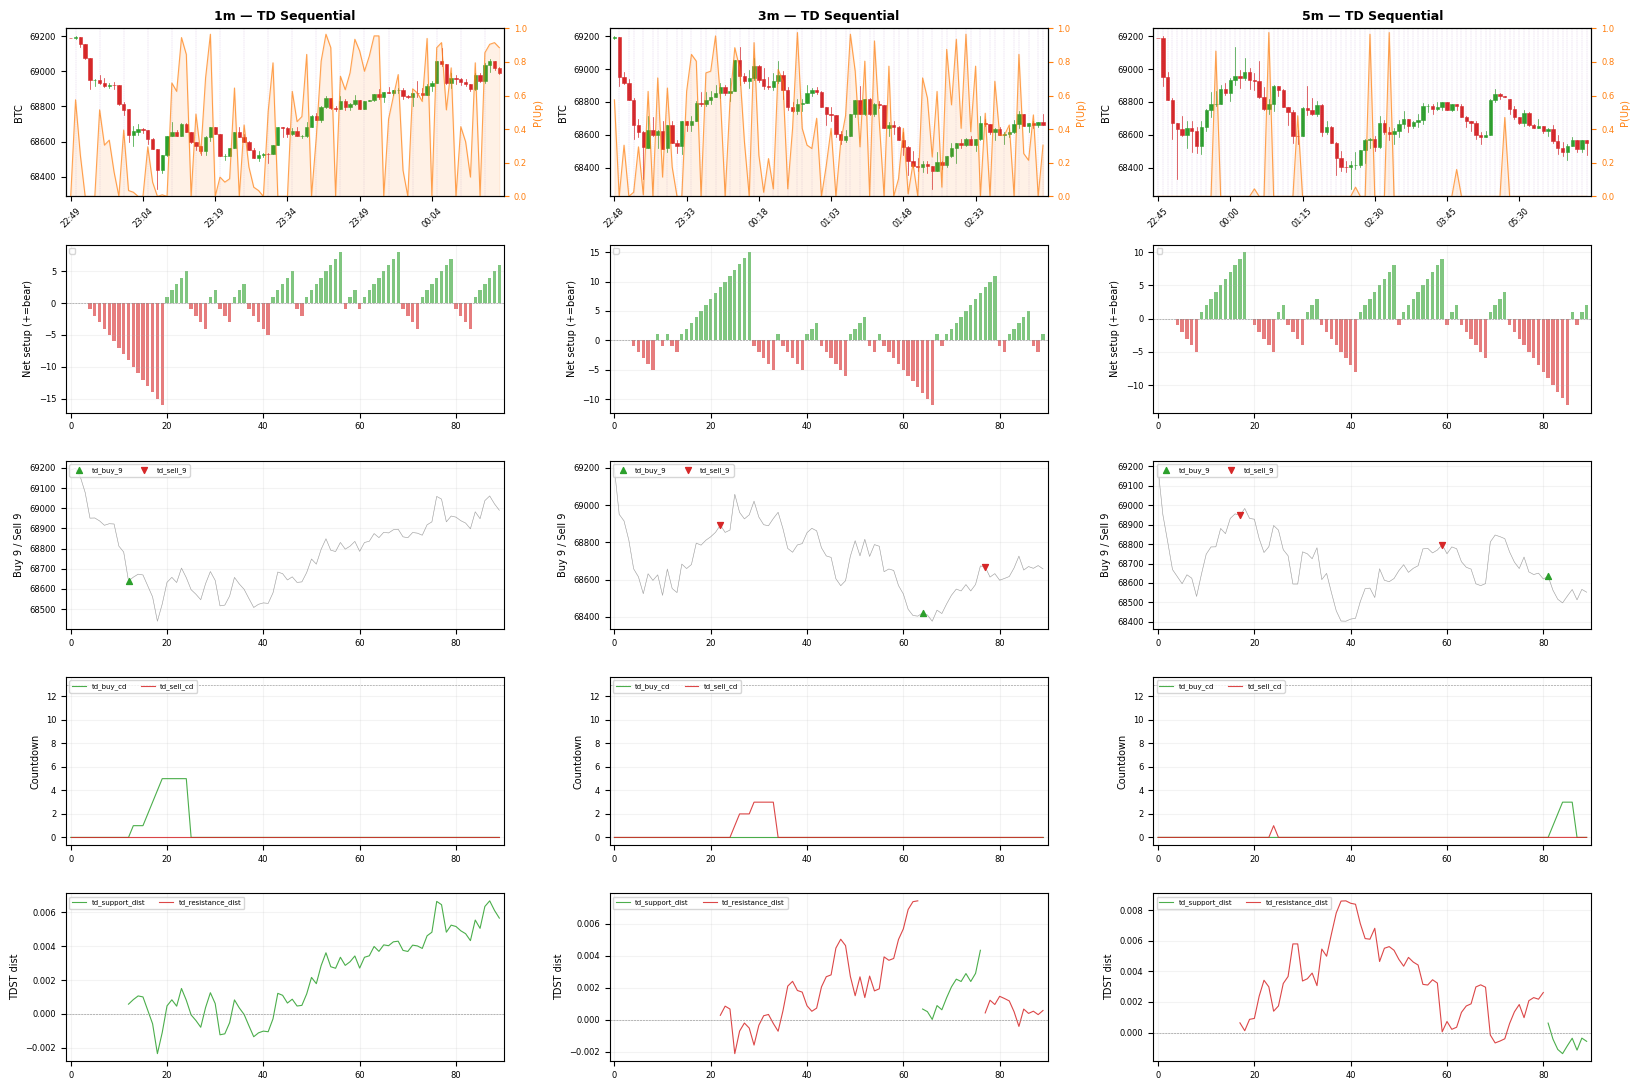

In [133]:
chart_indicator_group('TD Sequential', [
    {'cols': ['td_net_setup'], 'style': 'bar', 'levels': [0],
     'label': 'Net setup (+=bear)', 'colors': ['#2ca02c']},
    {'cols': ['td_buy_9', 'td_sell_9'], 'style': 'markers',
     'label': 'Buy 9 / Sell 9', 'colors': ['#2ca02c', '#d62728']},
    {'cols': ['td_buy_cd', 'td_sell_cd'], 'style': 'line', 'levels': [13],
     'label': 'Countdown', 'colors': ['#2ca02c', '#d62728']},
    {'cols': ['td_support_dist', 'td_resistance_dist'], 'style': 'line',
     'levels': [0], 'label': 'TDST dist',
     'colors': ['#2ca02c', '#d62728']},
])

### 10e. Returns & OBV

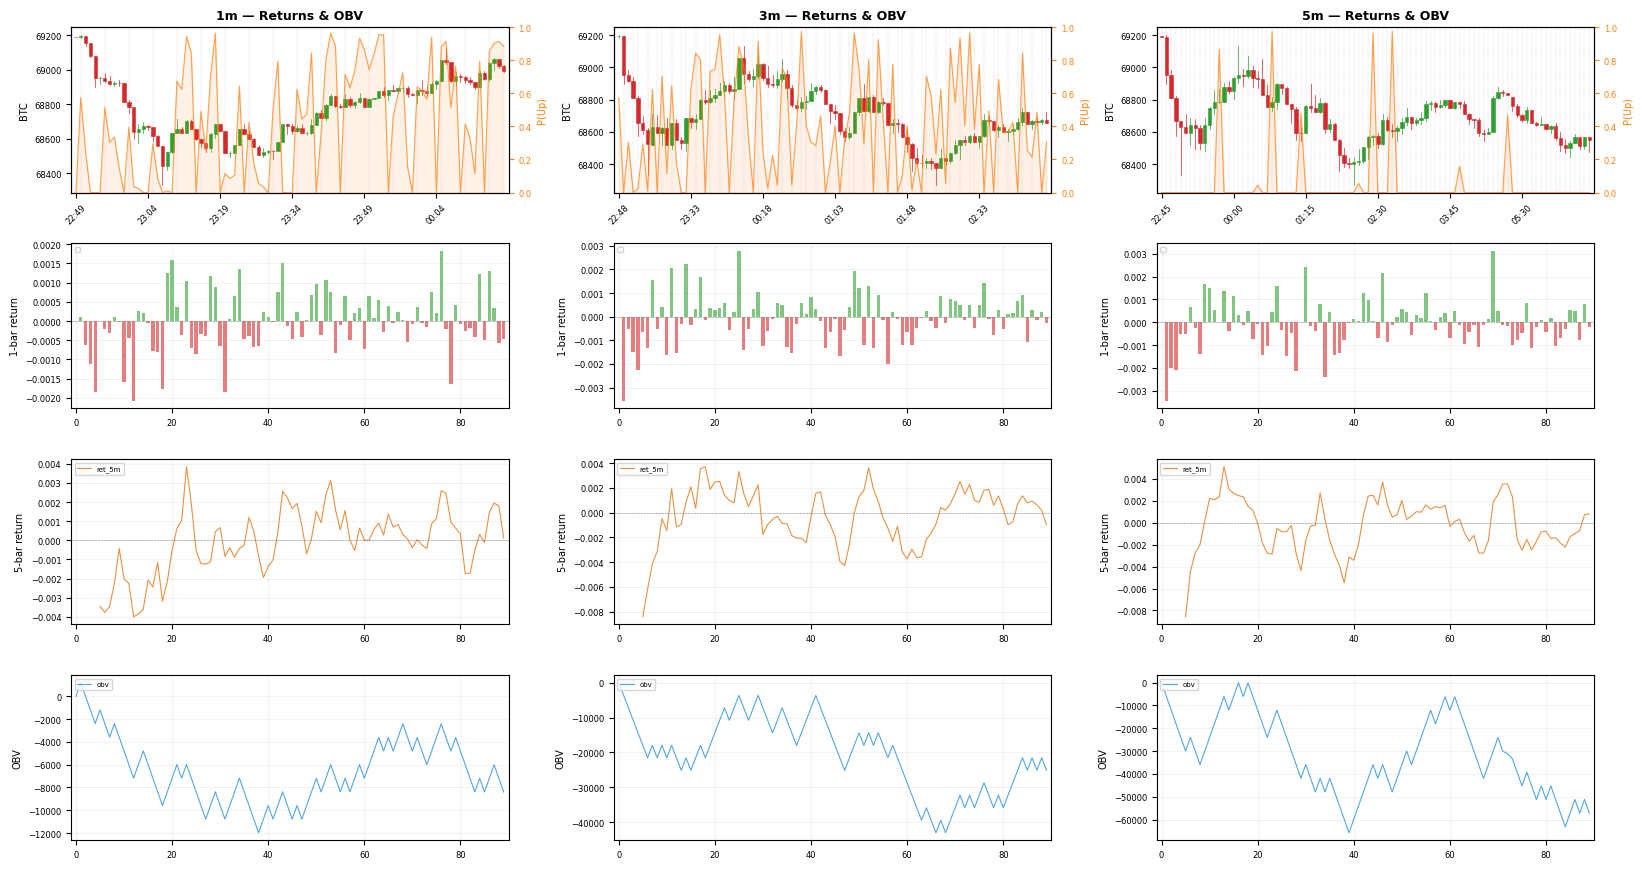

In [134]:
chart_indicator_group('Returns & OBV', [
    {'cols': ['ret_1m'], 'style': 'histogram', 'levels': [0],
     'label': '1-bar return', 'colors': ['#2ca02c']},
    {'cols': ['ret_5m'], 'style': 'line', 'levels': [0],
     'label': '5-bar return', 'colors': ['#e67e22']},
    {'cols': ['obv'], 'style': 'line', 'levels': [],
     'label': 'OBV', 'colors': ['#3498db']},
])

---

## 11. Microstructure features vs P(Up) — empirical relationship

For each microstructure feature from the v5 training data:
- Bin into 10 quantiles, compute empirical P(Up) per bin
- Scatter raw feature vs outcome (y=0/1) with binned trend line
- Pearson correlation and single-feature AUC

This answers: **does each feature alone carry monotonic signal for Polymarket direction?**

Loaded 10721 rows from ../models/logreg_v5/training_data.csv
y balance: Up=4215  Down=6506  rate=0.393
divergence = btc_ret_30s - poly_ret_5s  (mean=0.020267, std=0.183614)
Features found: ['depth_ratio', 'depth_skew', 'imbalance', 'spread', 'mid_return_5s', 'ret_30s', 'divergence', 'depth_change', 'acceleration', 'rolling_std_30s', 'range_30s', 'wall_flag']


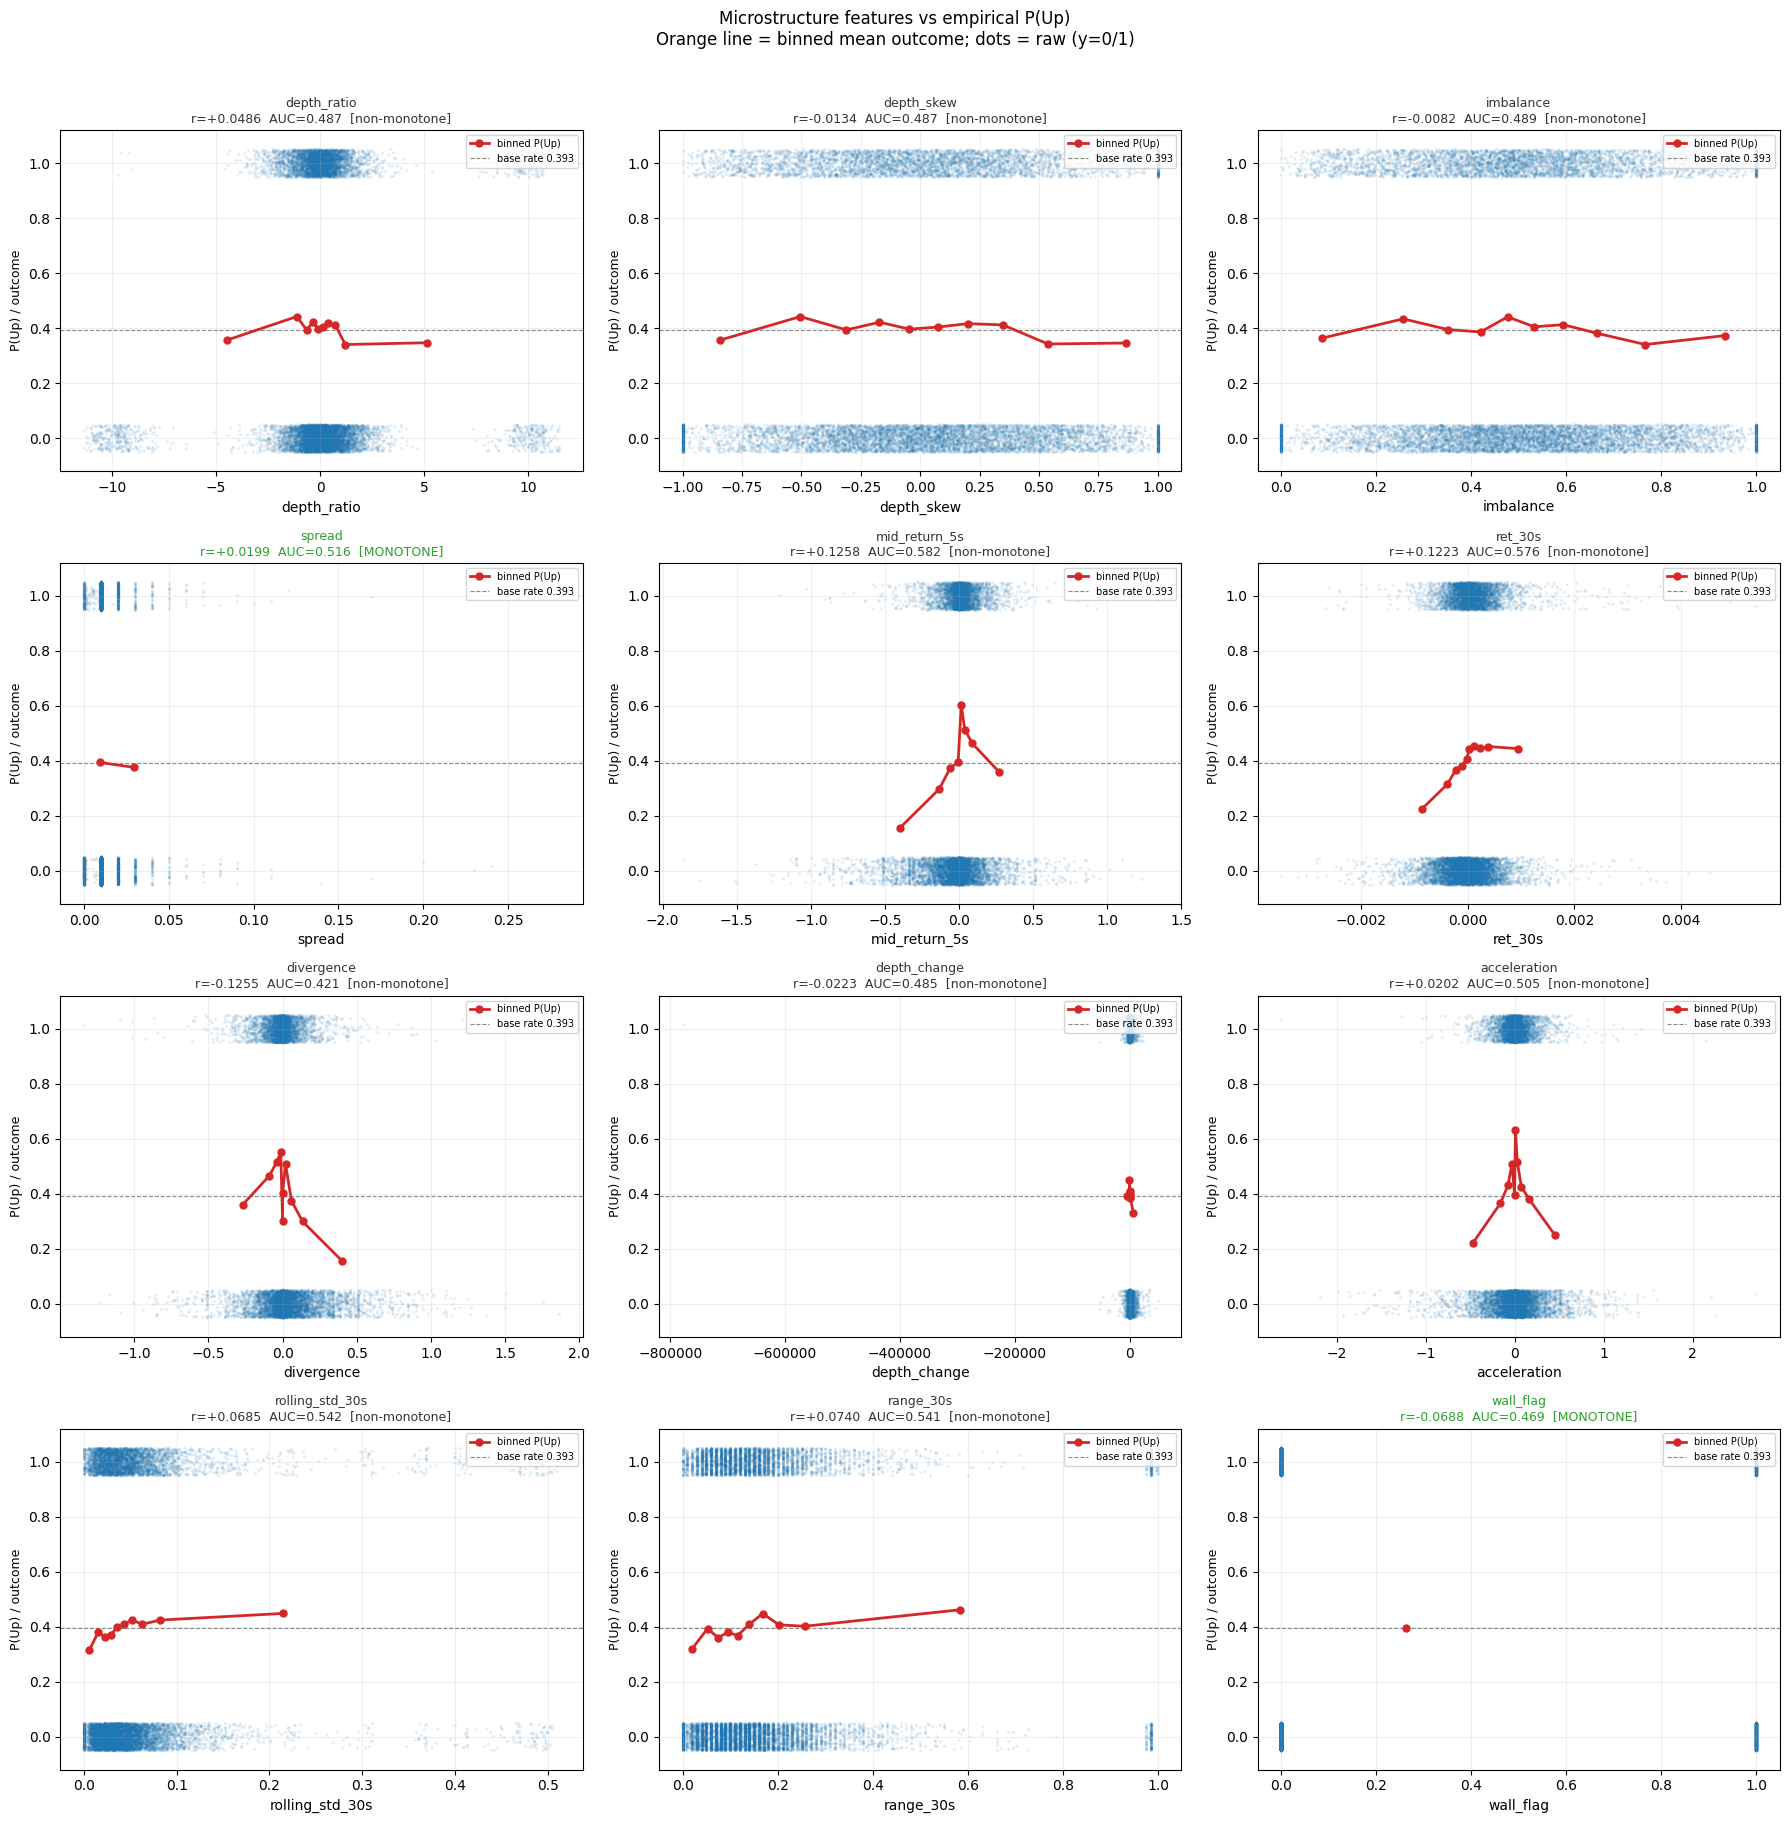


Single-feature predictive power:



,feature,pearson_r,AUC,monotonic,n_bins,P(Up) range
4,mid_return_5s,0.125791,0.581742,non-monotone,8,0.156 - 0.605
5,ret_30s,0.122274,0.575770,non-monotone,10,0.226 - 0.453
9,rolling_std_30s,0.068460,0.541728,non-monotone,10,0.313 - 0.448
10,range_30s,0.073979,0.541196,non-monotone,10,0.318 - 0.461
3,spread,0.019868,0.516317,MONOTONE,2,0.377 - 0.394
8,acceleration,0.020155,0.505461,non-monotone,10,0.220 - 0.633
2,imbalance,-0.008167,0.489409,non-monotone,10,0.340 - 0.441
1,depth_skew,-0.013435,0.486949,non-monotone,10,0.342 - 0.442
0,depth_ratio,0.048553,0.486687,non-monotone,10,0.340 - 0.442
7,depth_change,-0.022329,0.485091,non-monotone,10,0.330 - 0.450


In [135]:
from sklearn.metrics import roc_auc_score

# Load v5 training data (has y, features, and fill info)
v5_path = '../models/logreg_v5/training_data.csv'
if not os.path.exists(v5_path):
    v5_path = '../models/logreg_v5_tuned/training_data.csv'
df_v5 = pd.read_csv(v5_path)
print(f'Loaded {len(df_v5)} rows from {v5_path}')
print(f'y balance: Up={int(df_v5.y.sum())}  Down={int((df_v5.y==0).sum())}  rate={df_v5.y.mean():.3f}')

# Derived feature: BTC-vs-Poly divergence
# ret_30s = BTC 30s return, mid_return_5s = Polymarket Up mid 5s return
if 'ret_30s' in df_v5.columns and 'mid_return_5s' in df_v5.columns:
    df_v5['divergence'] = df_v5['ret_30s'] - df_v5['mid_return_5s']
    print(f'divergence = btc_ret_30s - poly_ret_5s  (mean={df_v5.divergence.mean():.6f}, std={df_v5.divergence.std():.6f})')

MICRO_FEATURES = [
    # core microstructure
    'depth_ratio', 'depth_skew', 'imbalance', 'spread', 'mid_return_5s',
    # BTC momentum
    'ret_30s',
    # divergence: BTC leads, Poly lags — positive = BTC up faster than Poly
    'divergence',
]
# Check which features actually exist in the dataset
available = [f for f in MICRO_FEATURES if f in df_v5.columns]
# Also add other v5 microstructure features present
extras = ['depth_change', 'acceleration', 'rolling_std_30s', 'range_30s', 'wall_flag']
available += [f for f in extras if f in df_v5.columns and f not in available]
print(f'Features found: {available}')

ncols = 3
nrows = (len(available) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes_flat = axes.flat if nrows > 1 else [axes] if ncols == 1 else axes.flat

stats_rows = []

for idx, feat in enumerate(available):
    ax = axes_flat[idx]
    x = df_v5[feat].values.astype(float)
    y = df_v5['y'].values.astype(int)
    mask = np.isfinite(x)
    x, y = x[mask], y[mask]

    # Scatter: feature vs y (jittered y for visibility)
    y_jit = y + np.random.uniform(-0.05, 0.05, len(y))
    ax.scatter(x, y_jit, s=2, alpha=0.08, c='#1f77b4', rasterized=True)

    # Bin into 10 quantiles and compute mean(y) per bin
    try:
        bins = pd.qcut(x, 10, labels=False, duplicates='drop')
    except ValueError:
        bins = pd.cut(x, 10, labels=False)
    bin_df = pd.DataFrame({'x': x, 'y': y, 'bin': bins})
    binned = bin_df.groupby('bin').agg(
        mean_x=('x', 'mean'),
        mean_y=('y', 'mean'),
        n=('y', 'size'),
    ).dropna()

    # Plot binned P(Up) as orange line with markers
    ax.plot(binned['mean_x'], binned['mean_y'], 'o-', color='#d62728',
            lw=2, ms=5, zorder=3, label='binned P(Up)')
    ax.axhline(df_v5['y'].mean(), color='#888', lw=0.8, ls='--',
               label=f'base rate {df_v5.y.mean():.3f}')

    # Correlation
    corr_r = float(np.corrcoef(x, y)[0, 1])

    # AUC (single feature)
    try:
        auc = roc_auc_score(y, x)
    except ValueError:
        auc = 0.5

    # Monotonicity check: are binned P(Up) values monotonically increasing or decreasing?
    diffs = np.diff(binned['mean_y'].values)
    mono_up = all(d >= -0.005 for d in diffs)
    mono_dn = all(d <= 0.005 for d in diffs)
    mono_label = 'MONOTONE' if (mono_up or mono_dn) else 'non-monotone'
    mono_color = '#2ca02c' if (mono_up or mono_dn) else '#e74c3c'

    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('P(Up) / outcome', fontsize=9)
    ax.set_title(f'{feat}\nr={corr_r:+.4f}  AUC={auc:.3f}  [{mono_label}]',
                 fontsize=9, color=mono_color if mono_label == 'MONOTONE' else '#333')
    ax.set_ylim(-0.12, 1.12)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)

    stats_rows.append({
        'feature': feat,
        'pearson_r': corr_r,
        'AUC': auc,
        'monotonic': mono_label,
        'n_bins': len(binned),
        'P(Up) range': f"{binned['mean_y'].min():.3f} - {binned['mean_y'].max():.3f}",
    })

# Hide unused axes
for idx in range(len(available), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Microstructure features vs empirical P(Up)\n'
             'Orange line = binned mean outcome; dots = raw (y=0/1)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
stats_df = pd.DataFrame(stats_rows).sort_values('AUC', ascending=False, key=abs)
print('\nSingle-feature predictive power:\n')
stats_df

### Feature interaction: pairwise scatter colored by outcome

Top 2 features by AUC plotted against each other, colored by y.
If classes separate visually, a linear model can exploit the joint signal.

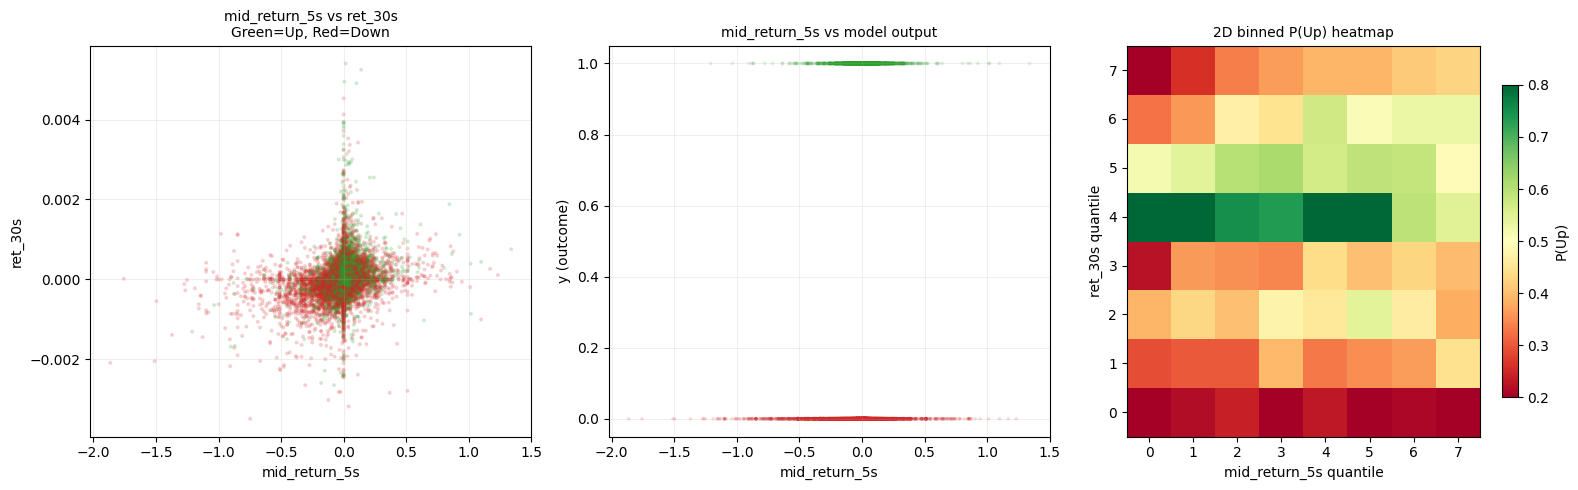

In [136]:
# Pick top 2 features by AUC
top2 = stats_df.head(2)['feature'].tolist()
if len(top2) == 2:
    f1, f2 = top2
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: f1 vs f2, colored by y
    ax = axes[0]
    colors = ['#d62728' if yi == 0 else '#2ca02c' for yi in df_v5['y']]
    ax.scatter(df_v5[f1], df_v5[f2], s=4, alpha=0.15, c=colors, rasterized=True)
    ax.set_xlabel(f1, fontsize=10)
    ax.set_ylabel(f2, fontsize=10)
    ax.set_title(f'{f1} vs {f2}\nGreen=Up, Red=Down', fontsize=10)
    ax.grid(True, alpha=0.2)

    # Panel 2: f1 vs p_up (if model predictions exist)
    ax = axes[1]
    if 'p_up' in df_v5.columns:
        ax.scatter(df_v5[f1], df_v5['p_up'], s=3, alpha=0.1, c=colors, rasterized=True)
        ax.set_ylabel('model p_up', fontsize=10)
    else:
        # Recompute p_up from the model if available
        ax.scatter(df_v5[f1], df_v5['y'], s=3, alpha=0.1, c=colors, rasterized=True)
        ax.set_ylabel('y (outcome)', fontsize=10)
    ax.set_xlabel(f1, fontsize=10)
    ax.set_title(f'{f1} vs model output', fontsize=10)
    ax.grid(True, alpha=0.2)

    # Panel 3: 2D binned heatmap of P(Up)
    ax = axes[2]
    try:
        q1 = pd.qcut(df_v5[f1], 8, labels=False, duplicates='drop')
        q2 = pd.qcut(df_v5[f2], 8, labels=False, duplicates='drop')
    except ValueError:
        q1 = pd.cut(df_v5[f1], 8, labels=False)
        q2 = pd.cut(df_v5[f2], 8, labels=False)
    heatmap = df_v5.assign(q1=q1, q2=q2).groupby(['q1','q2'])['y'].mean().unstack()
    im = ax.imshow(heatmap.values, aspect='auto', cmap='RdYlGn',
                   vmin=0.2, vmax=0.8, origin='lower')
    ax.set_xlabel(f'{f1} quantile', fontsize=10)
    ax.set_ylabel(f'{f2} quantile', fontsize=10)
    ax.set_title('2D binned P(Up) heatmap', fontsize=10)
    plt.colorbar(im, ax=ax, label='P(Up)', shrink=0.8)

    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 features for pairwise analysis')

---

## 12. Is the next Polymarket move predictable?

We test whether `P(X_{t+1} > X_t | features_t)` has signal.

**Target**: `y_next = 1` if the next observation's `up_mid` is higher than the current one, `0` otherwise.
Also a thresholded version that drops moves < 1 cent (noise).

**Feature groups**:
- **Price-only**: `X_t` (current `up_mid`)
- **BTC-only**: `ret_5s, ret_15s, ret_30s, ret_60s, vol_15s, vol_30s, vwap_deviation, cvd_60s, rsi_14`
- **Micro**: `spread, depth_ratio, depth_skew, imbalance, mid_return_5s, rolling_std_30s, range_30s, wall_flag, acceleration`
- **All**: price + BTC + micro + `time_to_expiry`

**Models**: Logistic Regression (L2) and XGBoost.
**Split**: strict time-based (first 80% of slots = train, last 20% = test). No row-level shuffle.
**Baselines**: random (AUC=0.5), price-only, BTC-only.

In [139]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/101.7 MB 18.4 MB/s eta 0:00:06
   --- ------------------------------------ 9.7/101.7 MB 25.2 MB/s eta 0:00:04
   ------ --------------------------------- 17.6/101.7 MB 29.9 MB/s eta 0:00:03
   --------- ------------------------------ 24.9/101.7 MB 30.9 MB/s eta 0:00:03
   ------------- -------------------------- 34.1/101.7 MB 33.8 MB/s eta 0:00:02
   ----------------- ---------------------- 44.6/101.7 MB 36.3 MB/s eta 0:00:02
   --------------------- ------------------ 55.3/101.7 MB 38.3 MB/s eta 0:00:02
   ------------------------- -------------- 65.8/101.7 MB 39.6 MB/s eta 0:00:01
   ----------------------------- ---------- 75.2/101.7 MB 40.7 MB/s eta 0:00:01
   --------------------------------- ------ 84.7/101.7 MB 41.2 MB/s eta 0:00:01
   ------------------------------------- -- 94.1/101.7 MB 41.4 MB/s eta 0:00:01
   --------------------------------------  101.4/10

The value specified in an AutoRun registry key could not be parsed.


In [140]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
import xgboost as xgb

# Load dataset
v5_path = '../models/logreg_v5/training_data.csv'
if not os.path.exists(v5_path):
    v5_path = '../models/logreg_v5_tuned/training_data.csv'
df = pd.read_csv(v5_path)

# ── Build next-step target (no leakage) ──
# Within each slot, shift up_mid by -1 to get next observation's mid
df = df.sort_values(['slot_ts', 'elapsed']).reset_index(drop=True)
df['up_mid_next'] = df.groupby('slot_ts')['up_mid'].shift(-1)
df = df.dropna(subset=['up_mid_next'])

# Classification target: did price go up?
df['y_next'] = (df['up_mid_next'] > df['up_mid']).astype(int)

# Thresholded: drop moves < 1 cent (noise)
df['delta_mid'] = df['up_mid_next'] - df['up_mid']
df_thresh = df[df['delta_mid'].abs() >= 0.01].copy()

print(f'Full dataset: {len(df)} rows, {df.slot_ts.nunique()} slots')
print(f'y_next balance: Up={df.y_next.sum()} ({df.y_next.mean():.3f})')
print(f'Thresholded (|delta|>=0.01): {len(df_thresh)} rows, '
      f'Up={df_thresh.y_next.sum()} ({df_thresh.y_next.mean():.3f})')

# ── Feature groups (no future data) ──
PRICE_FEATS = ['up_mid']
BTC_FEATS = ['ret_5s', 'ret_15s', 'ret_30s', 'ret_60s',
             'vol_15s', 'vol_30s', 'vwap_deviation', 'cvd_60s', 'rsi_14']
MICRO_FEATS = ['spread', 'depth_ratio', 'depth_skew', 'imbalance',
               'mid_return_5s', 'rolling_std_30s', 'range_30s',
               'wall_flag', 'acceleration']
ALL_FEATS = PRICE_FEATS + BTC_FEATS + MICRO_FEATS + ['time_to_expiry']

# Verify no leakage: all features are at time t, target is at t+1
print(f'\nFeature groups: price={len(PRICE_FEATS)}, btc={len(BTC_FEATS)}, '
      f'micro={len(MICRO_FEATS)}, all={len(ALL_FEATS)}')

# ── Strict time-based split by slot ──
slots = sorted(df['slot_ts'].unique())
split = int(len(slots) * 0.8)
train_slots = set(slots[:split])
test_slots  = set(slots[split:])

train = df[df.slot_ts.isin(train_slots)].reset_index(drop=True)
test  = df[df.slot_ts.isin(test_slots)].reset_index(drop=True)

train_t = df_thresh[df_thresh.slot_ts.isin(train_slots)].reset_index(drop=True)
test_t  = df_thresh[df_thresh.slot_ts.isin(test_slots)].reset_index(drop=True)

print(f'\nTrain: {len(train)} rows ({len(train_slots)} slots)')
print(f'Test:  {len(test)} rows ({len(test_slots)} slots)')
print(f'Thresh train: {len(train_t)}, test: {len(test_t)}')

Full dataset: 10397 rows, 324 slots
y_next balance: Up=3781 (0.364)
Thresholded (|delta|>=0.01): 7153 rows, Up=3526 (0.493)

Feature groups: price=1, btc=9, micro=9, all=20

Train: 8266 rows (259 slots)
Test:  2131 rows (65 slots)
Thresh train: 5734, test: 1419


In [141]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, is_xgb=False):
    """Fit model, predict on test, return metrics dict."""
    scaler = StandardScaler()
    Xs_tr = scaler.fit_transform(X_train)
    Xs_te = scaler.transform(X_test)

    if is_xgb:
        model.fit(Xs_tr, y_train, eval_set=[(Xs_te, y_test)], verbose=False)
    else:
        model.fit(Xs_tr, y_train)

    p = model.predict_proba(Xs_te)[:, 1]
    return {
        'name': name,
        'auc': roc_auc_score(y_test, p),
        'logloss': log_loss(y_test, np.clip(p, 1e-6, 1-1e-6)),
        'brier': brier_score_loss(y_test, p),
        'n_test': len(y_test),
        'base_rate': float(y_test.mean()),
        '_probs': p,
        '_model': model,
        '_scaler': scaler,
    }

# ── Run all experiments ──
configs = [
    ('Price only',     PRICE_FEATS),
    ('BTC only',       BTC_FEATS),
    ('Micro only',     MICRO_FEATS),
    ('Price + BTC',    PRICE_FEATS + BTC_FEATS),
    ('Price + Micro',  PRICE_FEATS + MICRO_FEATS),
    ('BTC + Micro',    BTC_FEATS + MICRO_FEATS),
    ('All features',   ALL_FEATS),
]

results = []
for label, feats in configs:
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, C=0.1, solver='lbfgs')
    r = evaluate_model(f'LR: {label}', lr,
                       train[feats].values, train['y_next'].values,
                       test[feats].values, test['y_next'].values)
    results.append(r)

    # XGBoost
    xg = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        eval_metric='logloss', early_stopping_rounds=20,
        use_label_encoder=False, verbosity=0,
    )
    r = evaluate_model(f'XGB: {label}', xg,
                       train[feats].values, train['y_next'].values,
                       test[feats].values, test['y_next'].values, is_xgb=True)
    results.append(r)

# Add random baseline
results.insert(0, {
    'name': 'Random baseline',
    'auc': 0.5,
    'logloss': -np.log(0.5),
    'brier': 0.25,
    'n_test': len(test),
    'base_rate': float(test['y_next'].mean()),
    '_probs': np.full(len(test), test['y_next'].mean()),
})

# ── Results table ──
res_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in results])
res_df = res_df.sort_values('auc', ascending=False)
print('=== Next-step prediction: full dataset (all moves) ===\n')
print(res_df.to_string(index=False, float_format='%.4f'))

=== Next-step prediction: full dataset (all moves) ===

              name    auc  logloss  brier  n_test  base_rate
 XGB: All features 0.7171   0.5809 0.1986    2131     0.3562
XGB: Price + Micro 0.7151   0.5811 0.1990    2131     0.3562
   XGB: Micro only 0.6996   0.5902 0.2031    2131     0.3562
  XGB: BTC + Micro 0.6984   0.5929 0.2037    2131     0.3562
  LR: All features 0.6930   0.5964 0.2055    2131     0.3562
 LR: Price + Micro 0.6878   0.5994 0.2066    2131     0.3562
   LR: BTC + Micro 0.6624   0.6161 0.2130    2131     0.3562
    LR: Micro only 0.6615   0.6181 0.2140    2131     0.3562
  XGB: Price + BTC 0.6463   0.6175 0.2154    2131     0.3562
   XGB: Price only 0.6205   0.6221 0.2179    2131     0.3562
   LR: Price + BTC 0.6070   0.6361 0.2230    2131     0.3562
    LR: Price only 0.5934   0.6401 0.2247    2131     0.3562
     XGB: BTC only 0.5620   0.6466 0.2271    2131     0.3562
      LR: BTC only 0.5586   0.6483 0.2280    2131     0.3562
   Random baseline 0.5000   0

In [142]:
# ── Thresholded (|delta| >= 1 cent) — removes noise ──
results_t = []
for label, feats in configs:
    if len(train_t) < 50 or len(test_t) < 20:
        continue
    lr = LogisticRegression(max_iter=1000, C=0.1, solver='lbfgs')
    r = evaluate_model(f'LR: {label}', lr,
                       train_t[feats].values, train_t['y_next'].values,
                       test_t[feats].values, test_t['y_next'].values)
    results_t.append(r)

    xg = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        eval_metric='logloss', early_stopping_rounds=20,
        use_label_encoder=False, verbosity=0,
    )
    r = evaluate_model(f'XGB: {label}', xg,
                       train_t[feats].values, train_t['y_next'].values,
                       test_t[feats].values, test_t['y_next'].values, is_xgb=True)
    results_t.append(r)

results_t.insert(0, {
    'name': 'Random baseline',
    'auc': 0.5,
    'logloss': -np.log(0.5),
    'brier': 0.25,
    'n_test': len(test_t),
    'base_rate': float(test_t['y_next'].mean()) if len(test_t) > 0 else 0.5,
})

res_t_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                          for r in results_t])
res_t_df = res_t_df.sort_values('auc', ascending=False)
print('=== Thresholded (|delta| >= 1 cent) ===\n')
print(res_t_df.to_string(index=False, float_format='%.4f'))

=== Thresholded (|delta| >= 1 cent) ===

              name    auc  logloss  brier  n_test  base_rate
 XGB: All features 0.7219   0.6151 0.2132    1419     0.4947
XGB: Price + Micro 0.7133   0.6207 0.2158    1419     0.4947
  LR: All features 0.7034   0.6288 0.2192    1419     0.4947
  XGB: BTC + Micro 0.6945   0.6347 0.2219    1419     0.4947
 LR: Price + Micro 0.6879   0.6377 0.2233    1419     0.4947
   XGB: Micro only 0.6858   0.6387 0.2240    1419     0.4947
   LR: BTC + Micro 0.6698   0.6491 0.2286    1419     0.4947
    LR: Micro only 0.6503   0.6595 0.2334    1419     0.4947
  XGB: Price + BTC 0.6251   0.6676 0.2377    1419     0.4947
   LR: Price + BTC 0.6186   0.6698 0.2388    1419     0.4947
   XGB: Price only 0.6075   0.6748 0.2411    1419     0.4947
    LR: Price only 0.5914   0.6805 0.2437    1419     0.4947
      LR: BTC only 0.5861   0.6790 0.2433    1419     0.4947
     XGB: BTC only 0.5757   0.6826 0.2448    1419     0.4947
   Random baseline 0.5000   0.6931 0.2500   

### Calibration curves — best model per feature group

A model that hugs the diagonal has well-calibrated probabilities.
Off-diagonal = the model's confidence doesn't match reality.

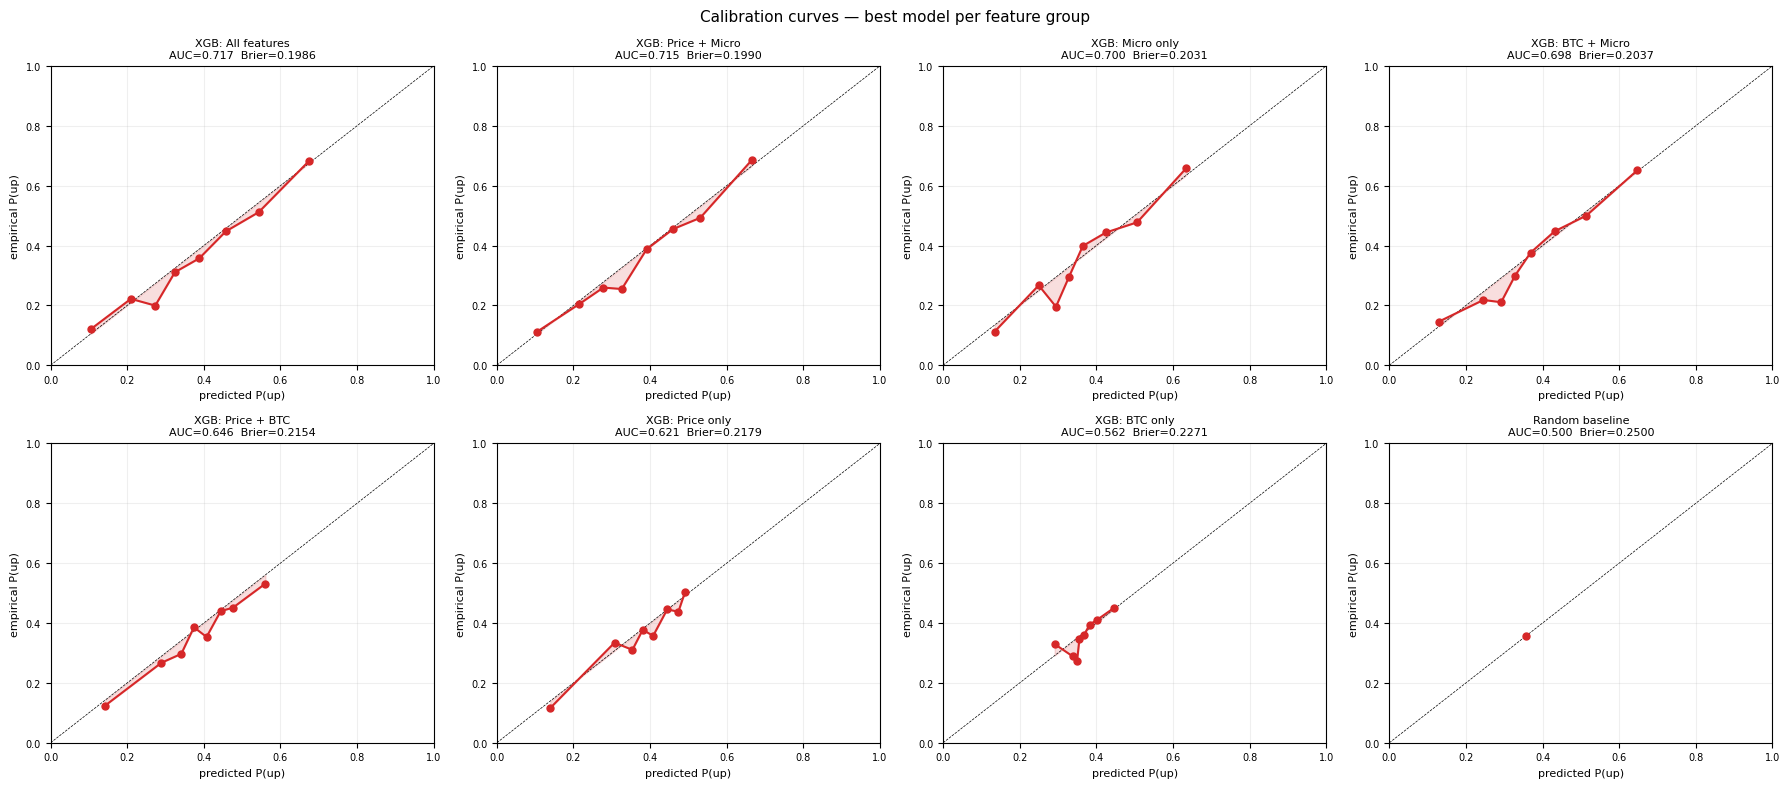

In [143]:
# Pick best model (by AUC) for each feature group for calibration plot
best_per_group = {}
for r in results:
    name = r['name']
    group = name.split(': ', 1)[1] if ': ' in name else name
    if group not in best_per_group or r['auc'] > best_per_group[group]['auc']:
        best_per_group[group] = r

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, (group, r) in enumerate(sorted(best_per_group.items(),
                                         key=lambda x: -x[1]['auc'])):
    if idx >= 8:
        break
    ax = axes.flat[idx]
    p = r.get('_probs')
    if p is None:
        continue
    y_te = test['y_next'].values

    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=8, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
    ax.plot(mean_pred, frac_pos, 'o-', color='#d62728', lw=1.5, ms=5)
    ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color='#d62728')
    ax.set_title(f'{r["name"]}\nAUC={r["auc"]:.3f}  Brier={r["brier"]:.4f}',
                 fontsize=8)
    ax.set_xlabel('predicted P(up)', fontsize=8)
    ax.set_ylabel('empirical P(up)', fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

for idx in range(len(best_per_group), 8):
    axes.flat[idx].set_visible(False)

plt.suptitle('Calibration curves — best model per feature group', fontsize=11)
plt.tight_layout()
plt.show()

### Feature importance — what drives predictions?

Logistic regression coefficients (scaled) and XGBoost gain importance for the "All features" model.

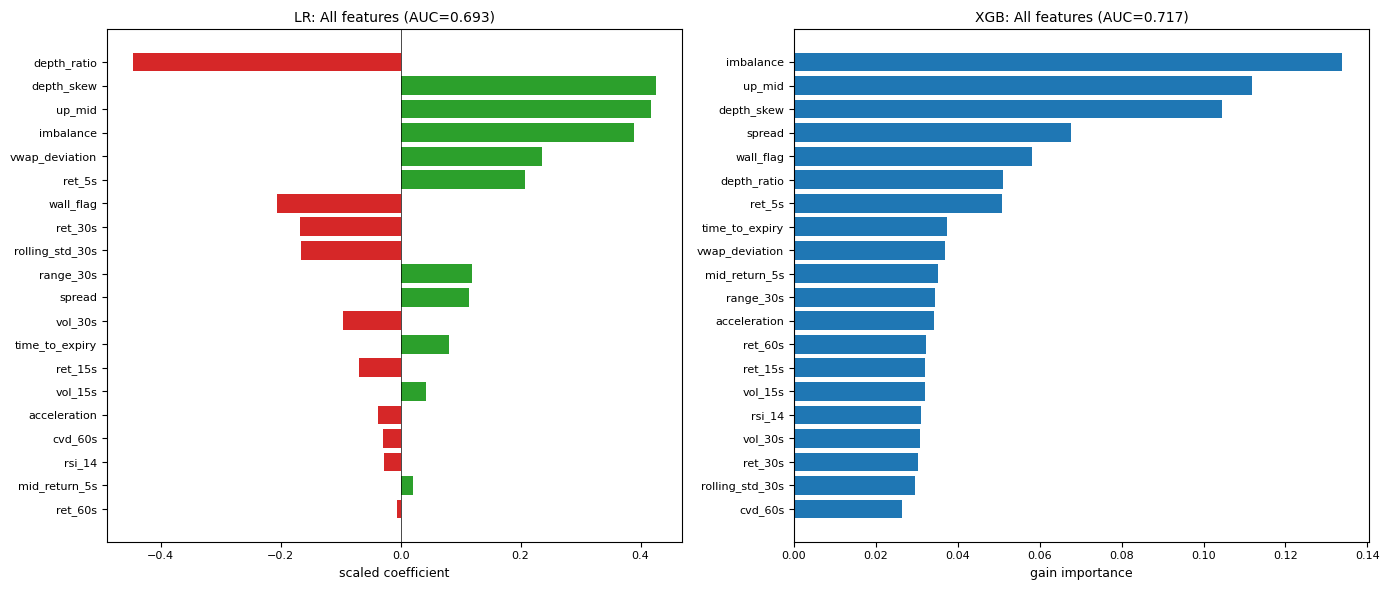


LR coefficients (sorted by |coef|):
        feature    coef  |coef|
    depth_ratio -0.4458  0.4458
     depth_skew  0.4255  0.4255
         up_mid  0.4174  0.4174
      imbalance  0.3884  0.3884
 vwap_deviation  0.2358  0.2358
         ret_5s  0.2069  0.2069
      wall_flag -0.2059  0.2059
        ret_30s -0.1678  0.1678
rolling_std_30s -0.1662  0.1662
      range_30s  0.1186  0.1186
         spread  0.1140  0.1140
        vol_30s -0.0960  0.0960
 time_to_expiry  0.0798  0.0798
        ret_15s -0.0687  0.0687
        vol_15s  0.0429  0.0429
   acceleration -0.0382  0.0382
        cvd_60s -0.0300  0.0300
         rsi_14 -0.0278  0.0278
  mid_return_5s  0.0208  0.0208
        ret_60s -0.0067  0.0067


In [144]:
# Find the All-features LR and XGB results
lr_all = [r for r in results if r['name'] == 'LR: All features'][0]
xgb_all = [r for r in results if r['name'] == 'XGB: All features'][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LR coefficients
lr_model = lr_all['_model']
coefs = lr_model.coef_[0]
imp_lr = pd.DataFrame({'feature': ALL_FEATS, 'coef': coefs})
imp_lr = imp_lr.reindex(imp_lr['coef'].abs().sort_values().index)
colors = ['#d62728' if c < 0 else '#2ca02c' for c in imp_lr['coef']]
ax1.barh(imp_lr['feature'], imp_lr['coef'], color=colors)
ax1.axvline(0, color='k', lw=0.5)
ax1.set_title(f'LR: All features (AUC={lr_all["auc"]:.3f})', fontsize=10)
ax1.set_xlabel('scaled coefficient', fontsize=9)
ax1.tick_params(labelsize=8)

# XGB importance
xgb_model = xgb_all['_model']
imp_xgb = pd.DataFrame({
    'feature': ALL_FEATS,
    'importance': xgb_model.feature_importances_,
})
imp_xgb = imp_xgb.sort_values('importance')
ax2.barh(imp_xgb['feature'], imp_xgb['importance'], color='#1f77b4')
ax2.set_title(f'XGB: All features (AUC={xgb_all["auc"]:.3f})', fontsize=10)
ax2.set_xlabel('gain importance', fontsize=9)
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# Print coefficients table
print('\nLR coefficients (sorted by |coef|):')
imp_lr_sorted = pd.DataFrame({'feature': ALL_FEATS, 'coef': coefs})
imp_lr_sorted['|coef|'] = imp_lr_sorted['coef'].abs()
print(imp_lr_sorted.sort_values('|coef|', ascending=False).to_string(index=False, float_format='%.4f'))

### Signal summary — does micro add value over price/BTC alone?

In [145]:
# Ablation: compare AUC lift of adding micro features
groups = {
    'Random': 0.5,
}
for r in results:
    groups[r['name']] = r['auc']

# Build comparison
print('=== Signal decomposition (AUC on held-out test set) ===\n')
print(f'{"Model":<30s} {"AUC":>8s} {"vs Random":>10s} {"vs Price":>10s}')
print('-' * 60)

price_auc = groups.get('LR: Price only', 0.5)
for name in ['Random baseline',
             'LR: Price only', 'LR: BTC only', 'LR: Micro only',
             'LR: Price + BTC', 'LR: Price + Micro', 'LR: BTC + Micro',
             'LR: All features',
             'XGB: Price only', 'XGB: BTC only', 'XGB: Micro only',
             'XGB: All features']:
    auc = groups.get(name)
    if auc is None:
        continue
    vs_rand = auc - 0.5
    vs_price = auc - price_auc
    flag = ' ***' if auc > 0.55 else ' *' if auc > 0.52 else ''
    print(f'{name:<30s} {auc:>8.4f} {vs_rand:>+10.4f} {vs_price:>+10.4f}{flag}')

print()
print('*** = strong signal (AUC > 0.55)')
print('*   = weak signal (AUC > 0.52)')
print()

# Interpretation
best = max(results, key=lambda r: r['auc'])
print(f'Best model: {best["name"]} with AUC={best["auc"]:.4f}')
if best['auc'] > 0.55:
    print('VERDICT: There IS predictive signal for next-step Polymarket moves.')
    print('This is potentially tradable, but verify on more data and with realistic fills.')
elif best['auc'] > 0.52:
    print('VERDICT: Weak signal detected. May be tradable with tight sizing, but')
    print('edge is thin and could be eaten by spread + fees.')
else:
    print('VERDICT: No meaningful predictive signal detected. Next-step Polymarket')
    print('moves appear close to random given these features. The market is efficient')
    print('at this frequency, or the features are too coarse.')

=== Signal decomposition (AUC on held-out test set) ===

Model                               AUC  vs Random   vs Price
------------------------------------------------------------
Random baseline                  0.5000    +0.0000    -0.0934
LR: Price only                   0.5934    +0.0934    +0.0000 ***
LR: BTC only                     0.5586    +0.0586    -0.0349 ***
LR: Micro only                   0.6615    +0.1615    +0.0681 ***
LR: Price + BTC                  0.6070    +0.1070    +0.0135 ***
LR: Price + Micro                0.6878    +0.1878    +0.0944 ***
LR: BTC + Micro                  0.6624    +0.1624    +0.0690 ***
LR: All features                 0.6930    +0.1930    +0.0995 ***
XGB: Price only                  0.6205    +0.1205    +0.0271 ***
XGB: BTC only                    0.5620    +0.0620    -0.0314 ***
XGB: Micro only                  0.6996    +0.1996    +0.1061 ***
XGB: All features                0.7171    +0.2171    +0.1237 ***

*** = strong signal (AUC > 0.55